# AFM simulation and CNN


**This notebook provides a complete example on how to create a simulated AFM dataset and how to train a regression model for post-processing.**

The first section simulates a dataset while the second section builds and trains a model. Finally, the user can test the model on their experimental data. The notebook provides two final **Output**; **1:** A simulated AFM dataset, **2:** A trained model ready to process experimental data.

## 1. Optional installations

Uncomment the lines you need in a fresh environment.

In [1]:
#!pip3 install deeplay plotly ipywidgets ipympl


## 2. Imports and configuration

Here we import necessary libraries and scripts.

In [2]:
import os

from __future__ import annotations

from dataclasses import dataclass
from typing import List

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

torch.set_num_threads(1)

We configure our simulator and model. The user must configure the experimental parameters, sample parameters and if desired the model parameters to adapt to their experimental setup.

1. **SimulationConfig**:
    1. The user must select the scan resolution that consists of pixel number $(n_x, n_y)$ and pixel size.
    2. Force-distance curve (FDC) parameters must be defined: $z~length$, $z~speed$, sampling frequency $f_s$ and $set-point~force$.
    3. Depending on the cantilever choice the tip shape and the desired thermal noise type must be selected.
    4. Curve mode must be selected between 'approach' and 'approach-retract'. This will depend on the used contact mechanics model.
3. **DatasetConfig**:
    1. Quantity of samples for training, validating and testing must be indicated.
    2. Topography types we want to use and the height range we are expecting.
    3. Range of stiffness for the substrate and the sample must be indicated. This is only an estimation and doesn't need to be precise.
5. **ModelConfig**:
    1. This contains the parameters of the model. The user does not need to adjust these values but it can b emodified if desired.

In [3]:
SEED = 69
np.random.seed(SEED)
torch.manual_seed(SEED)

Array = np.ndarray


@dataclass
class SimulationConfig:
    nx = 16
    ny = 16
    pixel_size_m = 2e-6
    z_length_m = 3e-6
    z_speed_um_s = 9.0
    sampling_frequency_hz = 9000
    setpoint_force_n = 1.0e-9
    tip_shape = "Sphere"
    include_thermal_noise = True
    noise_type = "experimental"
    experimental_noise_path = \
      "../data/thermal-noise-data_vDeflection_2025.11.28-16.42.57.tnd"
    curve_mode = "approach"  # options: "approach", "approach_retract"

@dataclass
class DatasetConfig:
    n_train_samples = 3
    n_val_samples = 1
    n_test_samples = 5
    topography_types = ("gaussian_features", "hemisphere")
    substrate_stiffness_range_pa = (5e3, 6e3)
    feature_stiffness_range_pa = (0.1e3, 4e3)
    height_range_m = (0.1e-6, 2e-6)
    contact_point_range_m = (0.01e-6, 2.9e-6)

@dataclass
class ModelConfig:
    batch_size = 256
    learning_rate = 2e-3
    max_epochs =1
    predict_contact_point = True
    cp_loss_weight = 0.5
    num_workers = 0
    accelerator = "cpu"
    devices = 1
    default_sample_to_display = 0


simulation_config = SimulationConfig()
dataset_config = DatasetConfig()
model_config = ModelConfig()

print(simulation_config)
print(dataset_config)
print(model_config)


SimulationConfig()
DatasetConfig()
ModelConfig()


## 3. Cantilever model with PSD


The `AFMCantilever` class represents the physical cantilever. Required inputs are: tip geometry, tip size, spring constant, resonance frequency, quality factor, and temperature — all available on the cantilever box or thermal calibration file.

The class handles two responsibilities: computing the contact area for a given indentation, and generating thermal noise. Three noise options are provided:

1. **Equipartition theorem**: The mean square displacement of the cantilever under thermal fluctuations is equal to $ k_B T / k $ under the equipartitoin theorem. In order to use this option the spring constant of the cantilever and the temperature we operate in must be known. Select 'rms' for the noise type.
   
2. **Theoretical PSD**: The cantilever behaves as a damped harmonic oscillator for which we can compute the power spectral density (PSD) that we denote as $S(f_x, f_y)$. Depending on our sampling frequency we compute a time domain noise from the theoretical PSD. Alongside the spring constant of the cantilever and the temperature, the user must also input the resonant frequency and the quality factor of the cantilever. Select 'Theoretical' for the noise type.
   
3. **Experimental PSD**: In the beginning of an AFM experiment the software measures the PSD of the cantilever in order to do thermal calibration. In this option the time domain noise is generated from the experimental PSD. Select 'Experimental' for the noise type and provide the path that leads to the '.tnd' calibration file.

In [4]:
class AFMCantilever:
    """AFM cantilever model with thermal-noise PSD support.

    This class represents the cantilever and stores parameters relevant to its
    thermal noise characteristics, allowing for both theoretical and
    experimental PSDs to be used in simulations.

    Parameters
    ----------
    k : float
        Spring constant in N/m.
    f0 : float
        Resonance frequency in Hz.
    Q : float
        Quality factor.
    T : float
        Temperature in kelvin.

    """

    def __init__(
        self,
        k: float =0.178,
        f0: float =7e3,
        Q: float =10.0,
        T: float =300.0
        ) -> None:
        self.k = k
        self.f0 = f0
        self.Q = Q
        self.T = T
        self.kB = 1.380649e-23
        self.m_eff = k / (2.0 * np.pi * f0) ** 2
        self.gamma = 2.0 * np.pi * f0 * self.m_eff / Q
        self._experimental_psd_cache = {}
        self._grid_psd_cache = {}

    def thermal_noise_rms(self):
        """Return the RMS thermal deflection in meters."""
        return np.sqrt(self.kB * self.T / self.k)

    def thermal_noise_psd_theoretical(
        self,
        frequency_hz: np.ndarray
        ) -> np.ndarray:
        """Return the one-sided theoretical displacement PSD.

        Parameters
        ----------
        frequency_hz : ndarray

        Returns
        -------
        np.ndarray
            PSD in m^2/Hz.

        """

        omega  = 2.0 * np.pi * frequency_hz
        omega0 = 2.0 * np.pi * self.f0
        denom  = (omega0**2 - omega**2)**2 + (omega * omega0 / self.Q)**2
        return (4.0 * self.kB * self.T * self.gamma) / (self.k**2 * denom)

    def thermal_noise_psd_experimental(
        self,
        path: str
        ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Load and cache an experimental displacement PSD.

        Loads the experimental PSD from the provided path. Converts the
        displacement from volts to meters using the metadata in the file.

        Parameters
        ----------
        path : str

        Returns
        -------
        tuple of np.ndarray
            (frequency_hz, spectral_density_x, spectral_density_x_fit)

        """

        cache_key = str(path)
        if cache_key not in self._experimental_psd_cache:
            data = np.loadtxt(path, skiprows=24)
            frequency_hz       = data[:, 0]
            spectral_density_v = data[:, 1]
            spectral_density_v_fit = data[:, 3]
            with open(path, "r") as f:
                lines = f.readlines()
            for line in lines:
                if "sensitivity" in line:
                    volts_to_displacement_nm = \
                      float(line.split(":")[1].split()[0])
                if "parameter.f" in line:
                    self.f0 = float(line.split(":")[1].split()[0]) * 1e3
                if "parameter.Q" in line:
                    self.Q = float(line.split(":")[1].split()[0])
            scale = volts_to_displacement_nm * 1e-9
            self._experimental_psd_cache[cache_key] = (
                frequency_hz,
                spectral_density_v     * scale**2,
                spectral_density_v_fit * scale**2,
            )
        return self._experimental_psd_cache[cache_key]

    def get_noise_psd(
        self,
        n_points: int,
        sampling_frequency_hz: float,
        noise_type: str = simulation_config.noise_type,
        experimental_path: str = simulation_config.experimental_noise_path
        ) -> tuple[np.ndarray, np.ndarray]:
        """Returns the simulation-grid PSD.

        Returns the theoretical PSD calculated with the harmonic oscillator
        model. When it's possible the cached results are reused.

        Parameters
        ----------
        n_points : int
        sampling_frequency_hz : float
        noise_type : str
        experimental_path : str or None

        Returns
        -------
        tuple of np.ndarray
            (frequency_hz, spectral_density_x)

        """

        cache_key = (noise_type.lower(), int(n_points), \
                     float(sampling_frequency_hz),None if experimental_path
                     is None else str(experimental_path))
        if cache_key in self._grid_psd_cache:
            return self._grid_psd_cache[cache_key]

        frequency_hz = np.fft.rfftfreq(n_points, d=1.0 / sampling_frequency_hz)
        if noise_type.lower() == "theoretical":
            spectral_density_x = \
              self.thermal_noise_psd_theoretical(frequency_hz)
        elif noise_type.lower() == "experimental":
            if experimental_path is None:
                raise ValueError("`experimental_path` must be provided for \
                experimental PSD.")
            frequency_hz, spectral_density_x, _ = (
                self.thermal_noise_psd_experimental(experimental_path)
            )
        else:
            raise ValueError(f"Unknown noise type: {noise_type}")

        self._grid_psd_cache[cache_key] = (frequency_hz, spectral_density_x)
        return self._grid_psd_cache[cache_key]

    def sample_thermal_noise(
        self,
        n_points: int,
        sampling_frequency_hz: float,
        noise_type: str = simulation_config.noise_type,
        experimental_path: str = simulation_config.experimental_noise_path,
        rng=None
        ) -> np.ndarray:
        """Draws one thermal-noise trace from the PSD.

        Draws one trace of thermal noise from the PSD using random phase and
        converts it to time domain noise using np.fft.irfft

        Parameters
        ----------
        n_points : int
        sampling_frequency_hz : float
        noise_type : str
        experimental_path : str or None
        rng : numpy.random.Generator or None

        Returns
        -------
        np.ndarray
            Noise trace in meters, shape (n_points,).

        """

        rng = np.random.default_rng() if rng is None else rng
        frequency_hz, spectral_density_x = self.get_noise_psd(
            n_points, sampling_frequency_hz, noise_type, experimental_path
        )
        df        = sampling_frequency_hz / n_points

        amplitude = n_points * \
                            np.sqrt(np.maximum(spectral_density_x * df/2, 0.0))
        coefficients = np.zeros(amplitude.shape[0], dtype=np.complex128)

        if amplitude.shape[0] > 2:
            phase = rng.uniform(0.0, 2.0 * np.pi, size=amplitude.shape[0] - 2)
            coefficients[1:-1] = amplitude[1:-1] * np.exp(1j * phase)
        coefficients[0] = 0.0
        if n_points % 2 == 0 and amplitude.shape[0] > 1:
            coefficients[-1] = amplitude[-1] * np.sign(rng.standard_normal())

        noise_m = np.fft.irfft(coefficients, n=n_points).real
        rms      = self.thermal_noise_rms()
        std      = np.std(noise_m)
        # Guard against zero std.
        if std > 0:
            noise_m = noise_m / std * rms
        else:
            noise_m = rng.normal(scale=rms, size=n_points)
        return noise_m


**Thermal noise from file**

Uncomment and run this cell if you wish to load an experimental thermal calibration file. When running locally, store the file in the folder with the script and make sure that the path is accessible.

In [5]:
# from google.colab import files
# import os

# print("Upload your experimental PSD text file (e.g., .txt or .csv):")
# uploaded = files.upload()
# for filename in uploaded.keys():
#      print(f'Uploaded "{filename}" ({len(uploaded[filename])} bytes)')
#      simulation_config.experimental_noise_path = filename
#      simulation_config.noise_type = "Experimental"


## 4. Contact mechanics


The `HertzContact` class transforms indentation depth into a force response. The Hertz model is provided as an example suited to biological applications. You can replace it with any contact model appropriate for your experiment.

In [6]:
class HertzContact:
    """Hertz contact model for spherical and pyramidal tips.

    Represents the relationship between indentation and force. Stores
    information related to contact geometry and contact mechanics.

    Parameters
    ----------
    R: float
        Tip radius in meters.
    nu: float
        Poisson ratio of the sample.
    alpha: float
        Pyramid face angle in degrees.

    """

    def __init__(
        self,
        R: float = 10e-9,
        nu: float = 0.5,
        alpha: float = 18.0
        ) -> None:
        self.R = R
        self.nu = nu
        self.alpha = alpha

    @property
    def alpha_rad(
        self
        ) -> float:
        """Return the pyramid face angle in radians."""
        return np.deg2rad(self.alpha)

    def hertz_sphere(
        self,
        indentation_m: float,
        stiffness_pa: float
        ) -> float:
        """Return the Hertz force for a spherical tip.

        Returns the force response of a purely elastic semi finite substrate
        with the given stiffness in response to given indentation depth for a
        spherical indentor.

        Parameters
        ----------
        indentation_m : float
            Indentation depth in meters.
        stiffness_pa : float
            Young's modulus in pascal.

        Returns
        -------
        float
            Contact force in newtons.

        """

        return (
            (4.0 / 3.0)
            * stiffness_pa
            * np.sqrt(self.R)
            * indentation_m**1.5
            / (1.0 - self.nu**2)
        )

    def hertz_cone(
        self,
        indentation_m: float,
        stiffness_pa: float
        ) -> float:
        """Return the Hertz-like force for a conical approximation.

        Returns the force response of a purely elastic semi finite substrate
        with the given stiffness in response to given indentation depth for a
        conical indentor.

        Parameters
        ----------
        indentation_m : float
            Indentation depth in meters.
        stiffness_pa : float
            Young's modulus in pascal.

        Returns
        -------
        float
            Contact force in newtons.

        """
        return (
            stiffness_pa
            * np.tan(self.alpha_rad)
            * indentation_m**2
            / (np.sqrt(2.0) * (1.0 - self.nu**2))
        )

    def force(
        self,
        cantilever_shape: str,
        indentation_m: float,
        stiffness_pa: float
        ) -> float:
        """Return the contact force for the given indentation.

        Parameters
        ----------
        cantilever_shape: str
            Tip geometry, either ``'Sphere'`` or ``'Pyramid'``.
        indentation_m: float
            Indentation depth in meters.
        stiffness_pa: float
            Young's modulus in pascal.

        Returns
        -------
        float
            Contact force in newtons.

        """

        indentation_safe_m = \
          np.maximum(np.asarray(indentation_m, dtype=np.float64), 0.0)
        if cantilever_shape == "Sphere":
            return self.hertz_sphere(indentation_safe_m, stiffness_pa)
        if cantilever_shape == "Pyramid":
            return self.hertz_cone(indentation_safe_m, stiffness_pa)
        raise ValueError(f"Unsupported cantilever shape: {cantilever_shape}")


## 5. Synthetic sample-map generator


The `SampleGenerator` class builds a synthetic sample. You provide topography type and mechanical property ranges; the class returns a 2D topography map, a stiffness map, and a **contact point map**.

### Contact point convention

The contact point is defined as the **absolute z-position along the displacement axis** at which the tip first touches the sample surface. A large contact-point value means the tip is still far from the surface when first contact occurs (i.e., the approach has barely started). A small value means the tip nearly traverses the full scan range before touching.




In [7]:
class SampleGenerator:
    """Generate topography, stiffness, and contact-point maps.

    Generates synthetic sample maps with specified topography types, stiffness
    ranges, and contact point ranges.

    """

    def __init__(
        self,
        substrate_stiffness_range_pa: tuple = (5e3, 10e3),
        feature_stiffness_range_pa: tuple = (2e3, 5e3),
        height_range_m: tuple = (1e-6, 4e-6),
        contact_point_range_m: tuple = (5.0e-6, 9.75e-6),
        ) -> None:
        self.substrate_stiffness_range_pa = substrate_stiffness_range_pa
        self.feature_stiffness_range_pa = feature_stiffness_range_pa
        self.height_range_m = height_range_m
        self.contact_point_range_m = contact_point_range_m

    def create_topography(
        self,
        size: tuple = (128, 128),
        pixel_size_m: float = 1e-6,
        topography_type: str = "gaussian_features",
        rng=None
        ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Create one synthetic sample map.

        Parameters
        ----------
        size: tuple
            Map dimensions as ``(ny, nx)`` in pixels.
        pixel_size_m: float
            Physical size of one pixel in meters.
        topography_type: str
            ``'gaussian_features'`` or ``'hemisphere'``.
        rng: Optional[numpy.random.Generator]
            Optional numpy random generator.

        Returns
        -------
        tuple[np.ndarray, np.ndarray, np.ndarray]
            Tuple of ``(topography_m, stiffness_map_pa, contact_point_map_m)``.

        """

        rng = np.random.default_rng() if rng is None else rng
        ny, nx = size
        topography_m = np.ones((ny, nx), dtype=np.float64) * 1e-8
        stiffness_map_pa = rng.uniform(
            self.substrate_stiffness_range_pa[0],
            self.substrate_stiffness_range_pa[1],
            size=(ny, nx),
        )

        if topography_type == "gaussian_features":
            n_features = int(rng.integers(4, 10))
            y, x = np.ogrid[0:ny, 0:nx]
            for _ in range(n_features):
                cx = int(rng.integers(0, nx))
                cy = int(rng.integers(0, ny))
                amplitude = float(rng.uniform(*self.height_range_m))
                sigma_px = float(rng.uniform(3.0, 10.0))
                gaussian = amplitude * np.exp(
                    -((x - cx) ** 2 + (y - cy) ** 2) / (2.0 * sigma_px**2)
                )
                topography_m += gaussian
        elif topography_type == "hemisphere":
            radius_px = min(nx, ny) // 4
            cx, cy = nx // 2, ny // 2
            y, x = np.ogrid[:ny, :nx]
            r2 = (x - cx) ** 2 + (y - cy) ** 2
            mask = r2 <= radius_px**2
            topography_m[mask] = self.height_range_m[1] * np.sqrt(
                1.0 - r2[mask] / radius_px**2
            )
        else:
            raise ValueError(f"Unsupported topography type: {topography_type}")

        feature_mask = topography_m > np.percentile(topography_m, 70.0)
        stiffness_map_pa[feature_mask] = rng.uniform(
            self.feature_stiffness_range_pa[0],
            self.feature_stiffness_range_pa[1],
            size=int(feature_mask.sum()),
        )

        if float(topography_m.max()) > float(topography_m.min()):
            normalized_topography = (topography_m - topography_m.min()) / (
                topography_m.max() - topography_m.min()
            )
        else:
            normalized_topography = np.zeros_like(topography_m)

        cp_min, cp_max = self.contact_point_range_m
        contact_point_map_m = np.interp(
            normalized_topography,
            (0.0, 1.0),
            (cp_max, cp_min),
        )
        contact_point_map_m = np.clip(contact_point_map_m, cp_min, cp_max)

        return topography_m, stiffness_map_pa, contact_point_map_m


## 6. AFM simulator


The `AFMSimulator` combines all previous classes into a vectorised map simulator. It returns 2D maps of force-distance curves, each with additive thermal noise.

In [9]:
class AFMSimulator:
    """AFM curve simulator with setpoint-triggered retract.

    Combines the cantilever dynamics with the contact model for every pixel in
    a given sample. The approach is stopped at the exact z-position where the
    Hertz force equals ``setpoint_force_n`` or exceeds it.

    Parameters
    ----------
    cantilever : AFMCantilever
        Cantilever model for the AFM simulation.
    contact_model : HertzContact
        Contact model for the AFM simulation.
    sample_generator : SampleGenerator
        Sample generator for the AFM simulation.
    config : SimulationConfig
        Configuration for the AFM simulation.

    """

    def __init__(
        self,
        cantilever,
        contact_model,
        sample_generator,
        config
        ) -> None:
        self.cantilever      = cantilever
        self.contact_model   = contact_model
        self.sample_generator = sample_generator
        self.config          = config
        self.n_points_approach = self._compute_n_points_approach()
        self.approach_axis_m   = self._build_approach_axis()

    def _compute_n_points_approach(
        self
        ) -> int:
        total_time_s = self.config.z_length_m / \
          (self.config.z_speed_um_s * 1e-6)
        return max(32, int(np.ceil(total_time_s * \
                                    self.config.sampling_frequency_hz)))

    def _build_approach_axis(
        self
        ) -> np.ndarray:
        return np.linspace(0.0, self.config.z_length_m, \
                           self.n_points_approach, \
                            endpoint=True, dtype=np.float64)

    def _retract_axis(
        self,
        z_start_m: float
        ) -> np.ndarray:
        """Return the retract displacement axis starting from ``z_start_m``."""
        z_stop_m = max(0.0, z_start_m - self.config.z_length_m)
        if z_stop_m >= z_start_m:
            return np.zeros(0, dtype=np.float64)
        n = max(1, int(np.ceil(
            (z_start_m - z_stop_m) / (self.config.z_speed_um_s * 1e-6) \
            * self.config.sampling_frequency_hz
        )))
        return np.linspace(z_start_m, z_stop_m, n + 1, \
                           endpoint=True)[1:].astype(np.float64)

    def simulate_force_map(
        self,
        stiffness_map_pa: np.ndarray,
        contact_point_map_m: np.ndarray,
        include_thermal_noise: bool = True,
        noise_type: str = simulation_config.noise_type,
        experimental_path: str = simulation_config.experimental_noise_path,
        rng: np.random.Generator = None
        ) -> dict:
        """Simulate a map of force curves with exact setpoint termination.

        Parameters
        ----------
        stiffness_map_pa : np.ndarray, shape (ny, nx)
            Stiffness map in pascals.
        contact_point_map_m : np.ndarray, shape (ny, nx)
            Contact point map in meters.
        include_thermal_noise : bool, optional
            Whether to include thermal noise in the simulation.
        noise_type : str, optional
            Type of noise to include. Options: "theoretical", "experimental".
        experimental_path : str or None, optional
            Path to experimental PSD file, if ``noise_type`` is "experimental".
        rng : numpy.random.Generator or None, optional
                Optional random number generator for reproducibility.

        Returns
        -------
        dict
            Keys: ``displacement_curves_m``, ``displacement_tip_curves_m``,
            ``force_curves_n``, ``measured_force_curves_n``,
            ``curve_lengths``, ``retract_start_indices``,
            ``contact_indices``.

        """

        rng = np.random.default_rng() if rng is None else rng
        ny, nx = stiffness_map_pa.shape

        # Vectorised approach force over the full grid.
        approach_indent = np.maximum(
            self.approach_axis_m[None, None, :] - \
                              contact_point_map_m[..., None], 0.0
        )
        approach_force = self.contact_model.force(
            cantilever_shape=self.config.tip_shape,
            indentation_m=approach_indent,
            stiffness_pa=stiffness_map_pa[..., None],
        )  # (ny, nx, n_points_approach)

        # First grid index where force >= setpoint.
        exceeded       = approach_force >= self.config.setpoint_force_n
        first_exceed   = np.argmax(exceeded, axis=-1)
        never_reached  = ~np.any(exceeded, axis=-1)
        first_exceed[never_reached] = self.n_points_approach - 1

        # Contact index (first sample at or past the contact point).
        contact_indices = np.clip(
            np.searchsorted(self.approach_axis_m, contact_point_map_m.ravel(),
                            side="left"),
            0, self.n_points_approach - 1,
        ).reshape(contact_point_map_m.shape)

        # Per-pixel variable-length curves.
        displacement_curves_m   = np.empty((ny, nx), dtype=object)
        displacement_tip_curves_m   = np.empty((ny, nx), dtype=object)
        force_curves_n          = np.empty((ny, nx), dtype=object)
        measured_force_curves_n = np.empty((ny, nx), dtype=object)
        curve_lengths           = np.zeros((ny, nx), dtype=np.int32)
        retract_start_indices   = np.zeros((ny, nx), dtype=np.int32)

        for r in range(ny):
            for c in range(nx):
                cp    = float(contact_point_map_m[r, c])
                E     = float(stiffness_map_pa[r, c])
                ei    = int(first_exceed[r, c])
                never = bool(never_reached[r, c])

                # ── approach ─────────────────────────────────────────────────
                if never or ei == 0:
                    app_z = self.approach_axis_m.copy()
                    app_f = approach_force[r, c].copy()
                else:
                    app_z = self.approach_axis_m[:ei]
                    app_f = approach_force[r, c, :ei]


                # ── retract ──────────────────────────────────────────────────
                ret_z = self._retract_axis(float(app_z[-1]))

                ret_f = self.contact_model.force(
                    self.config.tip_shape,
                    np.maximum(ret_z - cp, 0.0),
                    E,
                )

                cp_idx = int(contact_indices[r, c])
                tip_app_ind = app_z[cp_idx:] - \
                app_f[cp_idx:] / self.cantilever.k
                tip_app = np.concatenate([app_z[:cp_idx], tip_app_ind])
                tip_ret_ind = ret_z[cp_idx:] - \
                ret_f[cp_idx:] / self.cantilever.k
                tip_ret = np.concatenate([ret_z[:cp_idx], tip_ret_ind])

                if self.config.curve_mode == "approach":
                    disp_z = app_z
                    disp_tip = tip_app
                    force_n = app_f
                    retract_start = app_z.size  # no retract segment
                else:
                    disp_z  = np.concatenate([app_z, ret_z])
                    disp_tip  = np.concatenate([tip_app, tip_ret])
                    force_n = np.concatenate([app_f, ret_f])
                    retract_start = app_z.size
                # ── thermal noise ────────────────────────────────────────────
                noise_m = np.zeros_like(force_n)
                if include_thermal_noise:
                    if noise_type == "rms":
                        sigma = self.cantilever.thermal_noise_rms()
                        noise_m += np.random.normal(-sigma, sigma,
                                                    size=len(noise_m))
                    else:
                        noise_m = self.cantilever.sample_thermal_noise(
                            n_points=disp_z.size,
                            sampling_frequency_hz= \
                              self.config.sampling_frequency_hz,
                            noise_type=noise_type,
                            experimental_path=experimental_path,
                            rng=rng,
                        )

                displacement_curves_m[r, c]   = disp_z
                displacement_tip_curves_m[r, c]   = disp_tip
                force_curves_n[r, c]          = force_n
                measured_force_curves_n[r, c] = force_n + \
                noise_m * self.cantilever.k
                curve_lengths[r, c]           = disp_z.size
                retract_start_indices[r, c]   = retract_start

        return {
            "displacement_curves_m":   displacement_curves_m,
            "displacement_tip_curves_m":   displacement_tip_curves_m,
            "force_curves_n":          force_curves_n,
            "measured_force_curves_n": measured_force_curves_n,
            "curve_lengths":           curve_lengths,
            "retract_start_indices":   retract_start_indices,
            "contact_indices":         contact_indices,
        }


## 7. Plotting utilities


Helper functions for visualising simulator outputs.

In [10]:
def plot_maps(
    topography_m: ndarray,
    stiffness_map_pa: ndarray,
    contact_point_map_m: ndarray
    ) -> None:
    """Plot topography, stiffness, and contact-point maps side by side.

    Parameters
    ----------
    topography_m : np.ndarray
        Topography map in meters.
    stiffness_map_pa : np.ndarray
        Stiffness map in pascals.
    contact_point_map_m : np.ndarray
        Contact point map in meters.

    Returns
    -------
    None

    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    im0 = axes[0].imshow(topography_m * 1e6, cmap="viridis", aspect="equal")
    axes[0].set_title("Topography [µm]")
    axes[0].set_xlabel("X [pixel]")
    axes[0].set_ylabel("Y [pixel]")
    plt.colorbar(im0, ax=axes[0], shrink=0.8)

    im1 = axes[1].imshow(stiffness_map_pa / 1e3, cmap="magma", aspect="equal")
    axes[1].set_title("Stiffness [kPa]")
    axes[1].set_xlabel("X [pixel]")
    axes[1].set_ylabel("Y [pixel]")
    plt.colorbar(im1, ax=axes[1], shrink=0.8)

    im2 = axes[2].imshow(contact_point_map_m * 1e6, cmap="cividis",
                         aspect="equal")
    axes[2].set_title("Contact point [µm]")
    axes[2].set_xlabel("X [pixel]")
    axes[2].set_ylabel("Y [pixel]")
    plt.colorbar(im2, ax=axes[2], shrink=0.8)

    plt.tight_layout()
    plt.savefig('results/example_gaus.png')
    plt.show()


def plot_force_curve(
    displacement_curve_m: ndarray,
    displacement_tip_curve_m: ndarray,
    force_curve_n: ndarray,
    retract_start_index: int = None,
    valid_length: int = None,
    title: str = "Force curve"
   ) -> None:
    """Plot one force curve with approach and retract segments.

    Parameters
    ----------
    displacement_curve_m : np.ndarray
        Displacement axis in meters.
    displacement_tip_curve_m : np.ndarray
        Tip displacement axis in meters.
    force_curve_n : np.ndarray
        Force axis in newtons.
    retract_start_index : int, optional
        Index where the retract segment starts.
    valid_length : int, optional
        Number of valid points in the curve.
    title : str, optional
        Title of the plot.

    Returns
    -------
    None

    """
    if valid_length is None:
        valid_length = int(len(displacement_curve_m))
    if retract_start_index is None:
        retract_start_index = valid_length // 2

    displacement_curve_m = \
      np.asarray(displacement_curve_m[:valid_length], dtype=np.float64)
    displacement_tip_curve_m = \
      np.asarray(displacement_tip_curve_m[:valid_length], dtype=np.float64)
    force_curve_n = \
      np.asarray(force_curve_n[:valid_length], dtype=np.float64)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(
        displacement_curve_m[:retract_start_index] * 1e6,
        force_curve_n[:retract_start_index] * 1e9,
        label="Approach",
    )
    ax.plot(
        displacement_tip_curve_m[:retract_start_index] * 1e6,
        force_curve_n[:retract_start_index] * 1e9,
        label="Approach (tip)",
        linestyle='--'
    )
    ax.plot(
        displacement_curve_m[retract_start_index:] * 1e6,
        force_curve_n[retract_start_index:] * 1e9,
        label="Retract",
    )
    ax.plot(
        displacement_tip_curve_m[retract_start_index:] * 1e6,
        force_curve_n[retract_start_index:] * 1e9,
        label="Retract (tip)",
        linestyle='--'
    )
    ax.set_xlabel("Displacement [µm]")
    ax.set_ylabel("Force [nN]")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig('results/fdc_ex.png')
    plt.show()


def plot_psd(
    frequency_hz: np.ndarray,
    spectral_density_m2_per_hz: ndarray,
    cantilever,
    sampling_frequency: float,
    title: str = "Displacement PSD",
   ) -> None:
    """Plot a square-root displacement PSD on log-log axes.

    Parameters
    ----------
    frequency_hz : np.ndarray
        Frequency axis in hertz.
    spectral_density_m2_per_hz : np.ndarray
        Spectral density in m^2/Hz.
    cantilever : AFMCantilever
        Cantilever object containing parameters for plotting.
    sampling_frequency : float
        Sampling frequency in hertz, used to indicate the Nyquist frequency.
    title : str, optional
        Title of the plot.

    Returns
    -------
    None

    """

    fig, ax = plt.subplots(figsize=(7, 4))
    in_band = frequency_hz <= (sampling_frequency / 2.0)
    ax.loglog(
        frequency_hz / 1e3,
        np.sqrt(spectral_density_m2_per_hz),
        linewidth=2.0,
        label="Full PSD",
    )
    ax.loglog(
        frequency_hz[in_band] / 1e3,
        np.sqrt(spectral_density_m2_per_hz[in_band]),
        linewidth=2.0,
        label="Within Nyquist",
    )
    ax.axvline(
        cantilever.f0 / 1e3,
        color="red",
        linestyle="--",
        label=f"f0 = {cantilever.f0 / 1e3:.1f} kHz",
    )
    ax.set_xlabel("Frequency [kHz]")
    ax.set_ylabel("Sqrt(PSD) [m / sqrt(Hz)]")
    ax.set_title(title)
    ax.grid(alpha=0.3, which="both")
    ax.legend()
    plt.tight_layout()
    plt.savefig('results/psd_ex.png')
    plt.show()


## 8. Instantiate the simulator and generate one example sample

Approach points = 3000
Setpoint force = 1.00 nN


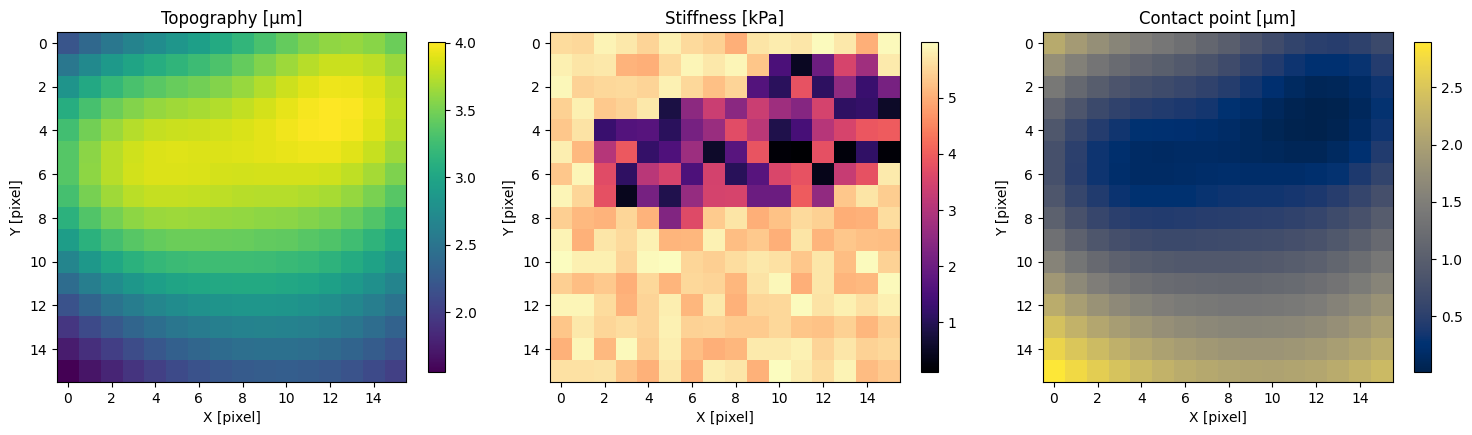

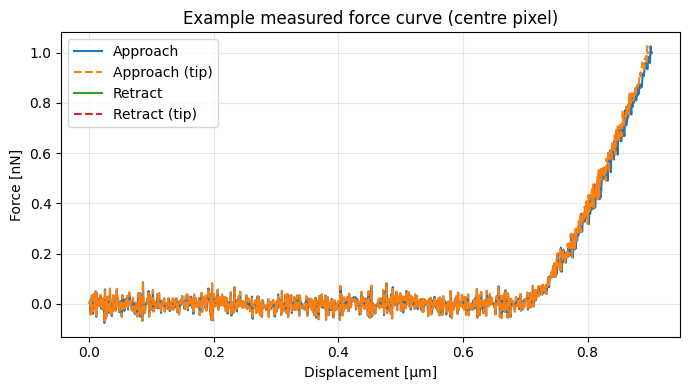

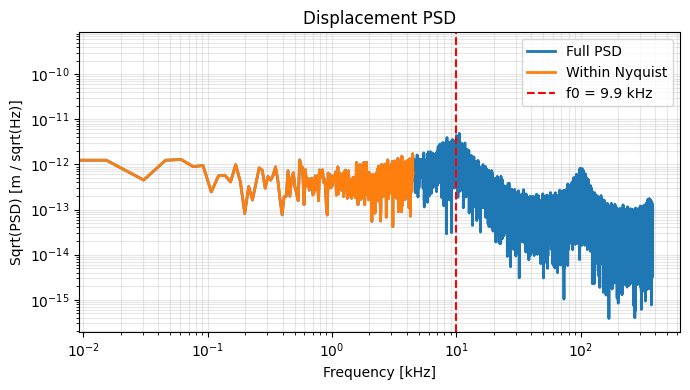

In [11]:
# We use the simulator to generate data and visualise it with the functions
# defined above.

rng = np.random.default_rng(SEED)

cantilever = AFMCantilever(k=0.178, f0=10e3, Q=100.0, T=300.0)
contact_model = HertzContact(R=1e-6, nu=0.5, alpha=18.0)
sample_generator = SampleGenerator(
    substrate_stiffness_range_pa=dataset_config.substrate_stiffness_range_pa,
    feature_stiffness_range_pa=dataset_config.feature_stiffness_range_pa,
    height_range_m=dataset_config.height_range_m,
    contact_point_range_m=dataset_config.contact_point_range_m,
)
simulator = AFMSimulator(
    cantilever=cantilever,
    contact_model=contact_model,
    sample_generator=sample_generator,
    config=simulation_config,
)

print(f"Approach points = {simulator.n_points_approach}")
print(f"Setpoint force = {simulation_config.setpoint_force_n * 1e9:.2f} nN")

example_topography_m, example_stiffness_pa, example_contact_point_m = (
    sample_generator.create_topography(
        size=(simulation_config.ny, simulation_config.nx),
        pixel_size_m=simulation_config.pixel_size_m,
        topography_type="gaussian_features",
        rng=rng,
    )
)

example_output = simulator.simulate_force_map(
    stiffness_map_pa=example_stiffness_pa,
    contact_point_map_m=example_contact_point_m,
    include_thermal_noise=simulation_config.include_thermal_noise,
    rng=rng,
)

plot_maps(example_topography_m, example_stiffness_pa, example_contact_point_m)

center_row = simulation_config.ny // 16
center_col = simulation_config.nx // 2
plot_force_curve(
    example_output["displacement_curves_m"][center_row, center_col],
    example_output["displacement_tip_curves_m"][center_row, center_col],
    example_output["measured_force_curves_n"][center_row, center_col],
    retract_start_index= \
      int(example_output["retract_start_indices"][center_row, center_col]),
    valid_length=int(example_output["curve_lengths"][center_row, center_col]),
    title="Example measured force curve (centre pixel)",
)

reference_points = max(simulator.n_points_approach * 2, 64)
if simulation_config.noise_type == "rms":
    frequency_hz, spectral_density_m2_per_hz = cantilever.get_noise_psd(
        n_points=reference_points,
        sampling_frequency_hz=cantilever.f0*10,
        noise_type="theoretical",
        experimental_path=simulation_config.experimental_noise_path,
    )

else:
    frequency_hz, spectral_density_m2_per_hz = cantilever.get_noise_psd(
        n_points=reference_points,
        sampling_frequency_hz=cantilever.f0*10,
        noise_type=simulation_config.noise_type,
        experimental_path=simulation_config.experimental_noise_path,
    )
plot_psd(
    frequency_hz,
    spectral_density_m2_per_hz,
    cantilever,
    sampling_frequency=simulation_config.sampling_frequency_hz,
)


## 9. Convert force curves into ML inputs

In [12]:
def compute_z_normalization(
    displacement_curves_tip_um: ndarray,
    valid_lengths: ndarray,
    z_scale_um: float = None
    ) -> dict:
    """Compute single-value global z scaling from training data.

    Computes a single global z scale from the 99th percentile of all valid z
    values across the training set.

    Parameters
    ----------
    displacement_curves_tip_um : ndarray, shape (n_samples, ny, nx, max_len)
        Displacement curves in micrometers.
    valid_lengths : ndarray, shape (n_samples, ny, nx)
        Valid lengths for each curve.
    z_scale_um : float or None
        If provided, use this fixed value directly.

    Returns
    -------
    dict
        Keys: ``z_scale_um``.

    """

    if z_scale_um is not None:
        return {"z_scale_um": float(z_scale_um)}

    n_samples, ny, nx, _ = displacement_curves_tip_um.shape
    z_values = []
    for s in range(n_samples):
        for r in range(ny):
            for c in range(nx):
                vl = int(valid_lengths[s, r, c])
                if vl > 0:
                    z_value = displacement_curves_tip_um[s, r, c, :vl]
                    z_values.append(np.asarray(z_value, dtype=np.float64))

    if not z_values:
        return {"z_scale_um": 1.0}

    all_valid_z = np.concatenate(z_values, axis=0)
    # Robust single-value scale; preserves absolute level (no per-curve
    # centering).
    z_scale = float(np.percentile(np.abs(all_valid_z), 99.0) + 1e-6)
    return {"z_scale_um": z_scale}


def build_force_inputs(
    measured_force_curves_nN: ndarray,
    displacement_curves_tip_um: ndarray,
    valid_lengths: ndarray,
    retract_start_indices: ndarray,
    z_normalization_stats: dict
    ) -> dict:
    """Build force, valid-mask, phase, and globally-scaled z channels.

    Each curve is kept at its full padded length. The valid mask is 1 inside
    the active curve and 0 in the idle-noise tail. The phase channel is -1
    during approach and +1 during retract. The z channel is scaled with one
    global value from training stats (divide-only).

    Parameters
    ----------
    measured_force_curves_nN : ndarray, shape (n_samples, ny, nx, max_len)
        Measured force curves in nanonewtons.
    displacement_curves_tip_um : ndarray, shape (n_samples, ny, nx, max_len)
        Displacement curves in micrometers.
    valid_lengths : ndarray, shape (n_samples, ny, nx)
        Valid lengths for each curve.
    retract_start_indices : ndarray, shape (n_samples, ny, nx)
        Indices where the retract phase starts for each curve.
    z_normalization_stats : dict
        Keys: ``z_scale_um``.

    Returns
    -------
    dict
        Keys: ``raw_force_nN``, ``valid_mask``, ``phase_channel``,
        ``z_scaled_channel``.

    """

    n_samples, ny, nx, _ = measured_force_curves_nN.shape
    valid_mask =np.zeros_like(measured_force_curves_nN, dtype=np.float32)
    phase_channel =np.zeros_like(measured_force_curves_nN, dtype=np.float32)
    z_scaled_channel =np.zeros_like(measured_force_curves_nN, dtype=np.float32)

    z_scale = float(z_normalization_stats["z_scale_um"])

    for s in range(n_samples):
        for r in range(ny):
            for c in range(nx):
                vl = int(valid_lengths[s, r, c])
                rs = int(retract_start_indices[s, r, c])
                if vl <= 0:
                    continue

                valid_mask[s, r, c, :vl] = 1.0
                phase_channel[s, r, c, :rs] = -1.0
                phase_channel[s, r, c, rs:vl] = 1.0

                z_valid = displacement_curves_tip_um[s, r, c, :vl]
                z_valid = np.asarray(z_valid, dtype=np.float64)
                z_scaled = (z_valid / (z_scale + 1e-30))
                z_scaled_channel[s, r, c, :vl] = z_scaled.astype(np.float32)

    return {
        "raw_force_nN": measured_force_curves_nN.astype(np.float32),
        "valid_mask": valid_mask,
        "phase_channel": phase_channel,
        "z_scaled_channel": z_scaled_channel,
    }


def compute_force_normalization(
    raw_force_nN: np.ndarray,
    valid_mask: np.ndarray
    ) -> dict:
    """Compute global force scaling from valid training points only.

    Computes a single global force scale from the 99th percentile of all valid
    force values across the training set.

    Parameters
    ----------
    raw_force_nN : np.ndarray
        Measured force curves in nanonewtons.
    valid_mask : np.ndarray
        Valid mask indicating active curve regions.

    Returns
    -------
    dict
        Keys: ``force_scale_nN``.

    """

    valid_values = raw_force_nN[valid_mask > 0.5]
    # Robust single-value force scale; preserves absolute level (divide-only).
    force_scale_nN = float(np.percentile(np.abs(valid_values), 99.0) + 1e-6)
    return {"force_scale_nN": force_scale_nN}


def normalize_force_channel(
    raw_force_nN: np.ndarray,
    valid_mask: np.ndarray,
    normalization_stats: dict
    ) -> np.ndarray:
    """Scale force channel with one global value; zero out padded tail.

    Scales the force channel by dividing by a single global force scale from
    training stats. The valid mask is applied to zero out the padded tail,
    ensuring that only the active curve regions contribute to the loss during
    training and that the model learns to predict zero force in the idle-noise
    tail.

    Parameters
    ----------
    raw_force_nN : np.ndarray
        Measured force curves in nanonewtons.
    valid_mask : np.ndarray
        Valid mask indicating active curve regions.
    normalization_stats : dict
        Keys: ``force_scale_nN``.

    Returns
    -------
    np.ndarray, float32
        Normalized force channel with the same shape as ``raw_force_nN``.

    """

    force_scale = float(normalization_stats["force_scale_nN"])
    normalized = raw_force_nN / (force_scale + 1e-30)
    return (normalized * valid_mask).astype(np.float32)


def flatten_sample_axes(
    input_tensor: np.ndarray,
    stiffness_maps_kpa: np.ndarray,
    contact_point_maps_nm: np.ndarray
    ) -> dict:
    """Flatten (n_samples, ny, nx, ...) arrays into a curve-wise dataset.

    Parameters
    ----------
    input_tensor : np.ndarray, shape(n_samples, ny, nx, n_channels, n_sequence)
        Input tensor containing curve-type data.
    stiffness_maps_kpa : np.ndarray
        Stiffness maps in kilopascals.
    contact_point_maps_nm : np.ndarray
        Contact point maps in nanometers.

    Returns
    -------
    dict
        Keys: ``curve_inputs``, ``stiffness_targets_kpa``,
        ``contact_point_targets_nm``.

    """

    n_samples, ny, nx, n_channels, n_sequence = input_tensor.shape
    return {
        "curve_inputs": input_tensor.reshape(n_samples * ny * nx, \
                                             n_channels, n_sequence),
        "stiffness_targets_kpa": stiffness_maps_kpa.reshape(-1),
        "contact_point_targets_nm": contact_point_maps_nm.reshape(-1),
    }


## 10. Generate train / validation / test sample sets

The split is done at the **sample-map level** to avoid train/test leakage between neighbouring pixels from the same synthetic sample.


In [13]:
def generate_sample_collection(
    n_samples: int,
    simulator: AFMSimulator,
    sample_generator: SampleGenerator,
    dataset_config: DatasetConfig,
    max_curve_length: int,
    seed: int
    ) -> dict:
    """Generate, simulate, and pad a collection of AFM sample maps.

    Curves are padded to ``max_curve_length`` with idle thermal noise so
    that all curves in the dataset share the same array length.

    Parameters
    ----------
    n_samples : int
        Number of samples to generate.
    simulator : AFMSimulator
        AFM simulator instance used to generate force maps.
    sample_generator : SampleGenerator
        Sample generator instance used to create topography maps.
    dataset_config : DatasetConfig
        Dataset configuration containing topography types and parameter ranges.
    max_curve_length : int
        All curves are padded to this length.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    dict
        Keys: ``topography_maps_nm``, ``stiffness_maps_kpa``,
        ``contact_point_maps_nm``, ``displacement_curves_um``,
        ``measured_force_curves_nN``, ``curve_lengths``,
        ``retract_start_indices``, ``contact_indices``.

    """

    rng = np.random.default_rng(seed)
    ny = simulator.config.ny
    nx = simulator.config.nx

    topography_maps_nm = np.zeros((n_samples, ny, nx), dtype=np.float32)
    stiffness_maps_kpa = np.zeros((n_samples, ny, nx), dtype=np.float32)
    contact_point_maps_nm = np.zeros((n_samples, ny, nx), dtype=np.float32)
    displacement_curves_tip_um = \
    np.zeros((n_samples, ny, nx, max_curve_length), dtype=np.float32)
    measured_force_curves_nN = \
    np.zeros((n_samples, ny, nx, max_curve_length), dtype=np.float32)
    curve_lengths = np.zeros((n_samples, ny, nx), dtype=np.int32)
    retract_start_indices = np.zeros((n_samples, ny, nx), dtype=np.int32)
    contact_indices = np.zeros((n_samples, ny, nx), dtype=np.int32)

    for i in range(n_samples):
        topography_type = rng.choice(dataset_config.topography_types)
        topo_m, stiff_pa, cp_m = sample_generator.create_topography(
            size=(ny, nx),
            pixel_size_m=simulator.config.pixel_size_m,
            topography_type=topography_type,
            rng=rng,
        )
        out = simulator.simulate_force_map(
            stiffness_map_pa=stiff_pa,
            contact_point_map_m=cp_m,
            include_thermal_noise=simulator.config.include_thermal_noise,
            noise_type=simulator.config.noise_type,
            experimental_path=simulator.config.experimental_noise_path,
            rng=rng,
        )

        topography_maps_nm[i] = topo_m * 1e9
        stiffness_maps_kpa[i] = stiff_pa / 1e3
        contact_point_maps_nm[i] = cp_m * 1e9
        curve_lengths[i] = out["curve_lengths"]
        retract_start_indices[i] = out["retract_start_indices"]
        contact_indices[i] = out["contact_indices"]

        for r in range(ny):
            for c in range(nx):
                vl = int(out["curve_lengths"][r, c])
                disp = out["displacement_tip_curves_m"][r, c]
                disp = np.asarray(disp, dtype=np.float64)
                meas = out["measured_force_curves_n"][r, c]
                meas = np.asarray(meas, dtype=np.float64)

                displacement_curves_tip_um[i, r, c, :vl] = disp * 1e6
                measured_force_curves_nN[i, r, c, :vl] = meas * 1e9

                # Pad the idle tail with thermal noise at the free-cantilever
                # level.
                pad_len = max_curve_length - vl
                if pad_len > 0:
                    displacement_curves_tip_um[i, r, c, vl:] = \
                    float(disp[-1]) * 1e6
                    noise_pad = simulator.cantilever.sample_thermal_noise(
                        n_points=pad_len,
                        sampling_frequency_hz= \
                        simulator.config.sampling_frequency_hz,
                        noise_type=simulator.config.noise_type,
                        experimental_path= \
                        simulator.config.experimental_noise_path,
                        rng=rng,
                    )
                    measured_force_curves_nN[i, r, c, vl:] = (
                        noise_pad * simulator.cantilever.k * 1e9
                    )

    return {
        "topography_maps_nm": topography_maps_nm,
        "stiffness_maps_kpa": stiffness_maps_kpa,
        "contact_point_maps_nm": contact_point_maps_nm,
        "displacement_curves_tip_um": displacement_curves_tip_um,
        "measured_force_curves_nN": measured_force_curves_nN,
        "curve_lengths": curve_lengths,
        "retract_start_indices": retract_start_indices,
        "contact_indices": contact_indices,
    }


# ── First pass: find global max curve length from training set ───────────────
# We simulate the training set at full approach length to determine the
# longest possible curve, then use that for all splits.
rng_scan = np.random.default_rng(SEED + 10)
max_curve_length = 0
for _ in range(dataset_config.n_train_samples):
    topo_type = rng_scan.choice(dataset_config.topography_types)
    _, stiff_pa, cp_m = sample_generator.create_topography(
        size=(simulation_config.ny, simulation_config.nx),
        pixel_size_m=simulation_config.pixel_size_m,
        topography_type=topo_type,
        rng=rng_scan,
    )
    out = simulator.simulate_force_map(
        stiffness_map_pa=stiff_pa,
        contact_point_map_m=cp_m,
        include_thermal_noise=False,
        rng=rng_scan,
    )
    max_curve_length = max(max_curve_length, int(out["curve_lengths"].max()))
    max_curve_length = int(max_curve_length * 1.02) + 10

print(f"Global max curve length: {max_curve_length}")

train_collection = generate_sample_collection(
    n_samples=dataset_config.n_train_samples,
    simulator=simulator,
    sample_generator=sample_generator,
    dataset_config=dataset_config,
    max_curve_length=max_curve_length,
    seed=SEED + 8,
)
val_collection = generate_sample_collection(
    n_samples=dataset_config.n_val_samples,
    simulator=simulator,
    sample_generator=sample_generator,
    dataset_config=dataset_config,
    max_curve_length=max_curve_length,
    seed=SEED + 12,
)
test_collection = generate_sample_collection(
    n_samples=dataset_config.n_test_samples,
    simulator=simulator,
    sample_generator=sample_generator,
    dataset_config=dataset_config,
    max_curve_length=max_curve_length,
    seed=SEED + 16,
)

# Use fixed physical z scaling to preserve absolute z information.
z_scale_um_fixed = simulation_config.z_length_m * 1e6
z_normalization_stats = compute_z_normalization(
    displacement_curves_tip_um=train_collection["displacement_curves_tip_um"],
    valid_lengths=train_collection["curve_lengths"],
    z_scale_um=z_scale_um_fixed,
)

train_force_inputs = build_force_inputs(
    measured_force_curves_nN=train_collection["measured_force_curves_nN"],
    displacement_curves_tip_um=train_collection["displacement_curves_tip_um"],
    valid_lengths=train_collection["curve_lengths"],
    retract_start_indices=train_collection["retract_start_indices"],
    z_normalization_stats=z_normalization_stats,
)
val_force_inputs = build_force_inputs(
    measured_force_curves_nN=val_collection["measured_force_curves_nN"],
    displacement_curves_tip_um=val_collection["displacement_curves_tip_um"],
    valid_lengths=val_collection["curve_lengths"],
    retract_start_indices=val_collection["retract_start_indices"],
    z_normalization_stats=z_normalization_stats,
)
test_force_inputs = build_force_inputs(
    measured_force_curves_nN=test_collection["measured_force_curves_nN"],
    displacement_curves_tip_um=test_collection["displacement_curves_tip_um"],
    valid_lengths=test_collection["curve_lengths"],
    retract_start_indices=test_collection["retract_start_indices"],
    z_normalization_stats=z_normalization_stats,
)

normalization_stats = compute_force_normalization(
    raw_force_nN=train_force_inputs["raw_force_nN"],
    valid_mask=train_force_inputs["valid_mask"],
)
normalization_stats.update(z_normalization_stats)

train_force_normalized = normalize_force_channel(
    train_force_inputs["raw_force_nN"], train_force_inputs["valid_mask"],
    normalization_stats,
)
val_force_normalized = normalize_force_channel(
    val_force_inputs["raw_force_nN"], val_force_inputs["valid_mask"],
    normalization_stats,
)
test_force_normalized = normalize_force_channel(
    test_force_inputs["raw_force_nN"], test_force_inputs["valid_mask"],
    normalization_stats,
)

def _stack(
    force_norm: np.ndarray,
    force_inputs: dict
    ) -> np.ndarray:
    return np.stack(
        [
            force_norm,
            force_inputs["valid_mask"],
            force_inputs["phase_channel"],
            force_inputs["z_scaled_channel"],
        ],
        axis=3,
    ).astype(np.float32)

train_flat = flatten_sample_axes(
    _stack(train_force_normalized, train_force_inputs),
    train_collection["stiffness_maps_kpa"],
    train_collection["contact_point_maps_nm"],
)
val_flat = flatten_sample_axes(
    _stack(val_force_normalized, val_force_inputs),
    val_collection["stiffness_maps_kpa"],
    val_collection["contact_point_maps_nm"],
)
test_flat = flatten_sample_axes(
    _stack(test_force_normalized, test_force_inputs),
    test_collection["stiffness_maps_kpa"],
    test_collection["contact_point_maps_nm"],
)

print("Train input shape:", train_flat["curve_inputs"].shape)
print("Val   input shape:", val_flat["curve_inputs"].shape)
print("Test  input shape:", test_flat["curve_inputs"].shape)
print("Normalization stats:", normalization_stats)


Global max curve length: 3213
Train input shape: (768, 4, 3213)
Val   input shape: (256, 4, 3213)
Test  input shape: (1280, 4, 3213)
Normalization stats: {'force_scale_nN': 0.911263644695282, 'z_scale_um': 3.0}


## 11. Dataset and model


In [15]:
# ── target normalisation ─────────────────────────────────────────────────────

def compute_target_normalization(
    stiffness_kpa: np.ndarray,
    contact_point_nm: np.ndarray
    ) -> dict:
    """Log-z-score stiffness and z-score contact-point statistics.

    Parameters
    ----------
    stiffness_kpa : np.ndarray
        Stiffness values in kilopascals.
    contact_point_nm : np.ndarray
        Contact point values in nanometers.

    Returns
    -------
    dict
        Keys: ``log_e_mean``, ``log_e_std``, ``cp_mean_nm``, ``cp_std_nm``.

    """

    log_e = np.log(np.asarray(stiffness_kpa, dtype=np.float64) + 1e-9)
    return {
        "log_e_mean": float(log_e.mean()),
        "log_e_std":  float(log_e.std()  + 1e-9),
        "cp_mean_nm": float(contact_point_nm.mean()),
        "cp_std_nm":  float(contact_point_nm.std() + 1e-9),
    }


def normalise_targets(
    stiffness_kpa: np.ndarray,
    contact_point_nm: np.ndarray,
    stats: dict
    ) -> tuple[np.ndarray, np.ndarray]:
    """Return normalised (log-z-scored E, z-scored cp) as float32.

    Parameters
    ----------
    stiffness_kpa : np.ndarray
        Stiffness values in kilopascals.
    contact_point_nm : np.ndarray
        Contact point values in nanometers.
    stats : dict
        Normalization statistics.

    Returns
    -------
    tuple of np.ndarray
        Normalized stiffness and contact point values.

    """

    log_e   = np.log(np.asarray(stiffness_kpa, dtype=np.float64) + 1e-9)
    norm_e = (log_e - stats["log_e_mean"]) / stats["log_e_std"]
    norm_e  = (norm_e).astype(np.float32)
    norm_cp = ((np.asarray(contact_point_nm, dtype=np.float64) \
      - stats["cp_mean_nm"]) / stats["cp_std_nm"]).astype(np.float32)
    return norm_e, norm_cp


def denormalise_stiffness(
    norm_e: np.ndarray,
    stats: dict
    ) -> np.ndarray:
    """Recover stiffness in kPa from normalised log-space.

    Parameters
    ----------
    norm_e : np.ndarray
        Normalized stiffness values.
    stats : dict
        Normalization statistics.

    Returns
    -------
    np.ndarray
        Denormalized stiffness values in kilopascals.

    """
    denormalized = np.exp(norm_e * stats["log_e_std"] + stats["log_e_mean"])

    return denormalized.astype(np.float32)


def denormalise_contact_point(
    norm_cp: np.ndarray,
    stats: dict
    ) -> np.ndarray:
    """Recover contact-point in nm from normalised space.

    Parameters
    ----------
    norm_cp : np.ndarray
        Normalized contact point values.
    stats : dict
        Normalization statistics.

    Returns
    -------
    np.ndarray
        Denormalized contact point values in nanometers.

    """
    denormalized = norm_cp * stats["cp_std_nm"] + stats["cp_mean_nm"]

    return denormalized.astype(np.float32)


target_stats = compute_target_normalization(
    stiffness_kpa=train_flat["stiffness_targets_kpa"],
    contact_point_nm=train_flat["contact_point_targets_nm"],
)
print("Target normalisation stats:", target_stats)


# ── dataset ──────────────────────────────────────────────────────────────────

class AFMDataset(
    Dataset
    ):
    """Curve-wise dataset with normalised targets.

    Parameters
    ----------
    curve_inputs : ndarray, shape (n_curves, n_channels, n_sequence)
        Input tensor containing curve-type data.
    norm_stiffness : ndarray, shape (n_curves,)
        Normalized stiffness values.
    norm_cp : ndarray, shape (n_curves,)
        Normalized contact point values.
    predict_contact_point : bool, optional
        If True, the dataset returns both stiffness and contact point targets.
        If False, only stiffness targets are returned.

    """

    curve_inputs:       torch.Tensor
    norm_stiffness:     torch.Tensor
    norm_cp:            torch.Tensor
    predict_contact_point: bool

    def __init__(
        self,
        curve_inputs: np.ndarray,
        norm_stiffness: np.ndarray,
        norm_cp: np.ndarray,
        predict_contact_point: bool = True
        ) -> None:
        self.curve_inputs          = torch.tensor(curve_inputs, \
                                                  dtype=torch.float32)
        self.norm_stiffness        = torch.tensor(norm_stiffness[:, None], \
                                                  dtype=torch.float32)
        self.norm_cp               = torch.tensor(norm_cp[:, None], \
                                                  dtype=torch.float32)
        self.predict_contact_point = predict_contact_point

    def __len__(
        self
        ) -> int:
        return int(self.curve_inputs.shape[0])

    def __getitem__(
        self,
        index: int
        ) -> tuple[torch.Tensor, torch.Tensor]:
        x = self.curve_inputs[index]
        if self.predict_contact_point:
            return x, torch.cat([self.norm_stiffness[index], \
                                 self.norm_cp[index]], dim=0)
        return x, self.norm_stiffness[index]


def make_loader(
    flat: dict,
    target_stats: dict,
    model_config: ModelConfig,
    shuffle: bool
     ) -> tuple[AFMDataset, DataLoader]:
    """Build a normalised AFMDataset and DataLoader for one split.

    Parameters
    ----------
    flat : dict
        Flattened dataset containing curve inputs and targets.
    target_stats : dict
        Normalization statistics for the targets.
    model_config : ModelConfig
        Configuration for the model.
    shuffle : bool
        Whether to shuffle the dataset.

    Returns
    -------
    tuple
        (dataset, dataloader)

    """

    norm_e, norm_cp = normalise_targets(
        flat["stiffness_targets_kpa"],
        flat["contact_point_targets_nm"],
        target_stats,
    )
    ds = AFMDataset(
        curve_inputs=flat["curve_inputs"],
        norm_stiffness=norm_e,
        norm_cp=norm_cp,
        predict_contact_point=model_config.predict_contact_point,
    )
    dl = DataLoader(ds, batch_size=model_config.batch_size,
                    shuffle=shuffle, num_workers=model_config.num_workers)
    return ds, dl


train_ds, train_dl = \
    make_loader(train_flat, target_stats, model_config, shuffle=True)
val_ds,   val_dl   = \
    make_loader(val_flat,   target_stats, model_config, shuffle=False)
test_ds,  test_dl  = \
    make_loader(test_flat,  target_stats, model_config, shuffle=False)
print("Dataset sizes (train / val / test):",
      len(train_ds), len(val_ds), len(test_ds))


# ── 1-D CNN ──────────────────────────────────────────────────────────────────

class AFMCurveCNN(nn.Module):
    """1-D CNN backbone + MLP head for AFM force-curve regression.

    Parameters
    ----------
    in_channels : int
        Number of input channels (force + valid_mask + phase + z_rel).
    hidden_channels : tuple of int
        Channel widths for the three convolutional blocks.
    predict_contact_point : bool

    Input
    -----
    x : float32
        Shape ``(batch, in_channels, n_points)``.

    Output
    ------
    float32 : shape ``(batch, 1)`` or ``(batch, 2)``.
        Normalised regression targets.

    Evaluation
    ----------
    >>> x = backbone(x)       # (B, C_last, T')
    >>> x = pool(x).squeeze() # global avg pool
    >>> x = head(x)           # (B, n_out)
    """

    backbone: nn.Module
    pool:     nn.Module
    head:     nn.Module
    predict_contact_point: bool

    def __init__(
        self,
        in_channels: int = 4,
        hidden_channels: tuple[int, int, int] = (16, 32, 64),
        predict_contact_point: bool = False
        ) -> None:
        super().__init__()
        self.predict_contact_point = predict_contact_point
        self.backbone = nn.Sequential(
            nn.Conv1d(in_channels, hidden_channels[0], \
                      kernel_size=7, padding=3),
            nn.BatchNorm1d(hidden_channels[0]), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(hidden_channels[0], hidden_channels[1], \
                      kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_channels[1]), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(hidden_channels[1], hidden_channels[2], \
                      kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_channels[2]), nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        out_features = 2 if predict_contact_point else 1
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels[2], 64), nn.ReLU(),
            nn.Linear(64, out_features),
        )

    def forward(self, x):
        return self.head(self.pool(self.backbone(x)))

Target normalisation stats: {'log_e_mean': 1.337843643798056, 'log_e_std': 0.7187871087008237, 'cp_mean_nm': 1520.9150390625, 'cp_std_nm': 718.1353759765625}
Dataset sizes (train / val / test): 768 256 1280


## 12. Deeplay application


In [16]:
import deeplay as dl
from deeplay.applications import Application
from deeplay.external import Adam
import torchmetrics as tm

print("Deeplay imported successfully.")


class AFMRegressionApp(Application):
    """Deeplay application for AFM stiffness and contact-point regression.

    Stiffness uses Huber loss on the log-z-scored value.
    Contact-point uses MSE on the z-scored value.
    Both targets are normalised before training (see cell above).

    Parameters
    ----------
    model : nn.Module
    learning_rate : float, optional
    predict_contact_point : bool, optional
    cp_loss_weight : float, optional
    huber_delta : float, optional

    """

    model:                 nn.Module
    predict_contact_point: bool
    cp_loss_weight:        float

    def __init__(
        self,
        model: nn.Module,
        learning_rate: float = 1e-3,
        predict_contact_point: bool = True,
        cp_loss_weight: float = 0.5,
        huber_delta: float = 1.0,
        metrics=None,
        **kwargs
        ) -> None:
        if metrics is None:
            metrics = [tm.MeanAbsoluteError(),
                       tm.MeanAbsolutePercentageError()]
        super().__init__(
            loss=nn.HuberLoss(delta=huber_delta),
            optimizer=Adam(lr=learning_rate),
            metrics=metrics,
            **kwargs,
        )
        self.model                 = model
        self.predict_contact_point = predict_contact_point
        self.cp_loss_weight        = cp_loss_weight

    def forward(
        self,
        x: torch.Tensor
        ) -> torch.Tensor:
        return self.model(x)

    def compute_loss(
        self,
        y_hat: torch.Tensor,
        y: torch.Tensor
        ) -> torch.Tensor:
        """Huber on normalised log-stiffness + weighted MSE on normalised cp.

        Parameters
        ----------
        y_hat : Tensor
        y : Tensor

        Returns
        -------
        Tensor
        """
        y = y.float()
        if not self.predict_contact_point:
            return self.loss(y_hat, y)
        return (
            self.loss(y_hat[:, :1], y[:, :1])
            + self.cp_loss_weight *
            nn.functional.mse_loss(y_hat[:, 1:2], y[:, 1:2])
        )


Deeplay imported successfully.


## 13. Train the regressor


/home/demirpehlivan/envnaz/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
I0000 00:00:1777327538.481168 1914984 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ HuberLoss        │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ AFMCurveCNN      │ 17.9 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 17.9 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 17.9 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 30                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/demirpehlivan/envnaz/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GeForce GTX 1050 Ti which is of cuda capability 6.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/home/demirpehlivan/envnaz/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/home/demirpehlivan/envnaz/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
NVIDIA GeForce GTX 1050 Ti with CUDA capability sm_61 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the NVIDIA GeForce GTX 1050 Ti GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

                          val_loss   = 0.96100


/home/demirpehlivan/envnaz/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/demirpehlivan/envnaz/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (3) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

                          val_loss   = 0.97029
  Epoch    1                   train_loss = 0.76357


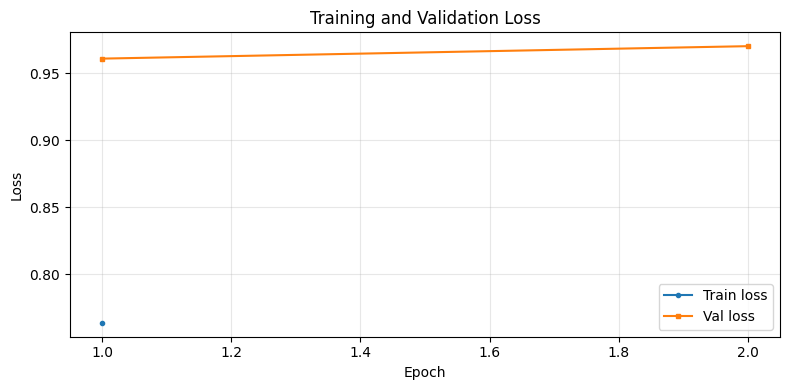

Checkpoint saved to models/afm_curve_cnn.pt     with curve_mode='approach'


In [19]:
try:
    from lightning.pytorch.callbacks import Callback as LightningCallback
except ImportError:
    from pytorch_lightning.callbacks import Callback as LightningCallback


class LossHistoryCallback(LightningCallback):
    """Records and prints train/val loss after every epoch."""

    def __init__(self):
        super().__init__()
        self.train_losses = []
        self.val_losses   = []

    def on_train_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        for key in ("train_loss", "loss", "train/loss"):
            if key in metrics:
                v = float(metrics[key])
                self.train_losses.append(v)
                print(f"  Epoch {trainer.current_epoch + 1:4d} \
                  train_loss = {v:.5f}")
                break

    def on_validation_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        for key in ("val_loss", "val/loss", "validation_loss"):
            if key in metrics:
                v = float(metrics[key])
                self.val_losses.append(v)
                print(f"  {'':10s}              val_loss   = {v:.5f}")
                break


loss_history = LossHistoryCallback()

model = AFMCurveCNN(
    in_channels=4,
    hidden_channels=(16, 32, 64),
    predict_contact_point=model_config.predict_contact_point,
)

application = AFMRegressionApp(
    model=model,
    learning_rate=model_config.learning_rate,
    predict_contact_point=model_config.predict_contact_point,
    cp_loss_weight=model_config.cp_loss_weight,
)

trainer_config = {
    "max_epochs": model_config.max_epochs,
    "accelerator": model_config.accelerator,
    "devices": model_config.devices,
    "callbacks": [loss_history],
}

trainer = dl.Trainer(**trainer_config)

checkpoint_path = "models/afm_curve_cnn.pt"

# Create checkpoint with curve_mode stored
checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_config": {
        "in_channels": 4,
        "hidden_channels": (16, 32, 64),
        "predict_contact_point": model_config.predict_contact_point,
    },
    "target_stats": target_stats,
    "normalization_stats": normalization_stats,
    "curve_mode": simulation_config.curve_mode,
}

trainer.fit(
    application,
    train_dataloaders=train_dl,
    val_dataloaders=val_dl,
)

# ── Plot train / val loss ────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 4))
if loss_history.train_losses:
    ax.plot(
        range(1, len(loss_history.train_losses) + 1),
        loss_history.train_losses,
        label="Train loss",
        marker="o",
        markersize=3,
        linewidth=1.5,
    )
if loss_history.val_losses:
    ax.plot(
        range(1, len(loss_history.val_losses) + 1),
        loss_history.val_losses,
        label="Val loss",
        marker="s",
        markersize=3,
        linewidth=1.5,
    )
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/training_loss.png", dpi=150)
plt.show()

# Update checkpoint after training
trained_model = model
checkpoint["model_state_dict"] = trained_model.state_dict()
torch.save(checkpoint, checkpoint_path)
print(f"Checkpoint saved to {checkpoint_path} \
    with curve_mode='{simulation_config.curve_mode}'")

## 14. Evaluate on the test set


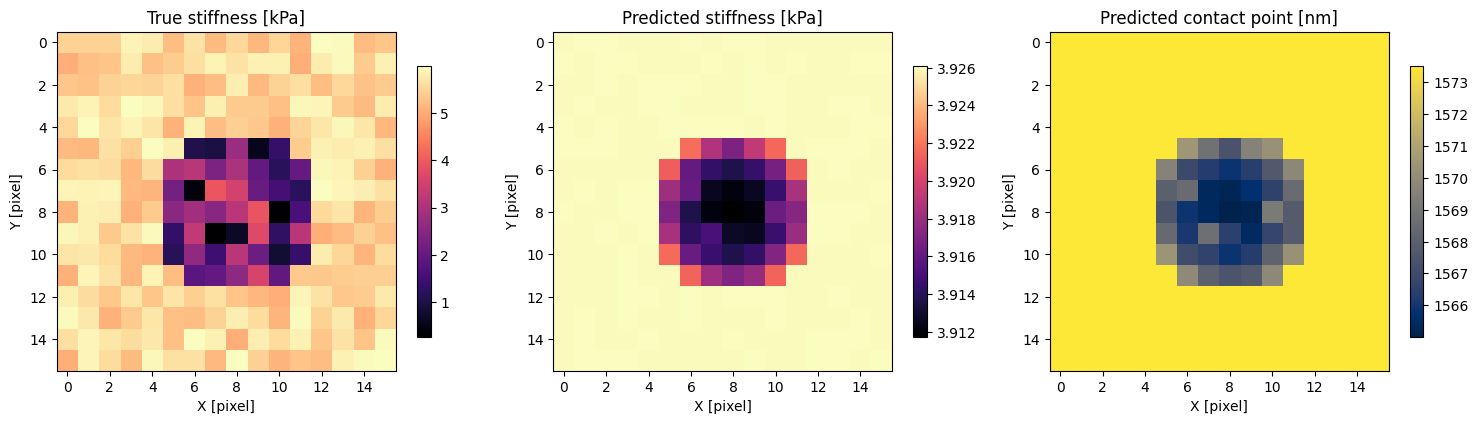

Test stiffness RMSE: 1.71 kPa
Test contact-point RMSE: 1085.2 nm


In [21]:
def predict_and_denormalise(
    model: nn.Module,
    curve_inputs: np.ndarray,
    target_stats: dict,
    batch_size: int = 256, device: torch.device = None,
    predict_contact_point: bool = True
    ) -> dict:
    """Run inference and de-normalise to physical units.

    Runs the model in batches on the provided curve inputs, then applies the
    inverse of the normalisation transforms to recover stiffness in kPa and
    contact point in nm.

    Parameters
    ----------
    model : nn.Module
        Trained PyTorch model for inference.
    curve_inputs : ndarray
        Input curves for the model.
    target_stats : dict
        Statistics for de-normalisation.
    batch_size : int, optional
        Batch size for inference.
    device : torch.device, optional
        Device for inference.
    predict_contact_point : bool, optional
        Whether to predict contact points.

    Returns
    -------
    dict
        ``stiffness_predictions_kpa`` and optionally ``cp_predictions_nm``.

    """

    # device = torch.device("cpu") if device is None else device
    model.eval()
    norm_e_list, norm_cp_list = [], []

    with torch.no_grad():
        for start in range(0, curve_inputs.shape[0], batch_size):
            pred = model(
                torch.tensor(curve_inputs[start:start + batch_size], \
                              dtype=torch.float32, device=device)
            ).cpu().numpy()
            norm_e_list.append(pred[:, 0])
            if predict_contact_point:
                norm_cp_list.append(pred[:, 1])

    out = {"stiffness_predictions_kpa": denormalise_stiffness(
        np.concatenate(norm_e_list), target_stats
    )}
    if predict_contact_point:
        out["cp_predictions_nm"] = denormalise_contact_point(
            np.concatenate(norm_cp_list), target_stats
        )
    return out


prediction_output = predict_and_denormalise(
    model=trained_model,
    curve_inputs=test_flat["curve_inputs"],
    target_stats=target_stats,
    batch_size=model_config.batch_size,
    device="cpu",
    predict_contact_point=model_config.predict_contact_point,
)

predicted_stiffness_maps_kpa = \
  prediction_output["stiffness_predictions_kpa"].reshape(
    test_collection["stiffness_maps_kpa"].shape
)
predicted_contact_point_maps_nm = None
if model_config.predict_contact_point:
    predicted_contact_point_maps_nm = \
      prediction_output["cp_predictions_nm"].reshape(
        test_collection["contact_point_maps_nm"].shape
    )

sample_to_display = model_config.default_sample_to_display
n_panels = 3 if model_config.predict_contact_point else 2
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4))
axes = np.atleast_1d(axes)

im_true = axes[0].imshow(
    test_collection["stiffness_maps_kpa"][sample_to_display],
    cmap="magma")
axes[0].set_title("True stiffness [kPa]")
axes[0].set_xlabel("X [pixel]"); axes[0].set_ylabel("Y [pixel]")
plt.colorbar(im_true, ax=axes[0], shrink=0.8)

im_pred = axes[1].imshow(
    predicted_stiffness_maps_kpa[sample_to_display],
    cmap="magma")
axes[1].set_title("Predicted stiffness [kPa]")
axes[1].set_xlabel("X [pixel]"); axes[1].set_ylabel("Y [pixel]")
plt.colorbar(im_pred, ax=axes[1], shrink=0.8)

if model_config.predict_contact_point:
    im_cp = axes[2].imshow(
        predicted_contact_point_maps_nm[sample_to_display],
        cmap="cividis")
    axes[2].set_title("Predicted contact point [nm]")
    axes[2].set_xlabel("X [pixel]"); axes[2].set_ylabel("Y [pixel]")
    plt.colorbar(im_cp, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.savefig('output.png')
plt.show()


stiffness_rmse = np.sqrt(np.mean(
    (predicted_stiffness_maps_kpa - test_collection["stiffness_maps_kpa"]) ** 2
))
print(f"Test stiffness RMSE: {stiffness_rmse:.2f} kPa")

if model_config.predict_contact_point:
    cp_rmse = np.sqrt(np.mean(
        (predicted_contact_point_maps_nm - \
         test_collection["contact_point_maps_nm"]) ** 2
    ))
    print(f"Test contact-point RMSE: {cp_rmse:.1f} nm")


In [23]:
from pathlib import Path

save_dir = Path("models")
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / "afm_curve_cnn_8.pt"
checkpoint = {
    "model_state_dict": trained_model.state_dict(),
    "target_stats": target_stats,
    "normalization_stats": {
        **normalization_stats,
        "max_curve_length": int(max_curve_length),
        "z_length_nm": float(simulation_config.z_length_m * 1e9),
    },
    "model_config": {
        "in_channels": int(train_flat["curve_inputs"].shape[1]),
        "hidden_channels": (16, 32, 64),
        "predict_contact_point": model_config.predict_contact_point,
        "max_curve_length": int(max_curve_length),
    },
    "curve_mode": simulation_config.curve_mode,
}

torch.save(checkpoint, save_path)
print(f"Saved model to: {save_path} \
    with curve_mode='{simulation_config.curve_mode}'")


Saved model to: models/afm_curve_cnn_8.pt     with curve_mode='approach'


## 15. Clickable stiffness-map viewer


In [24]:
from pathlib import Path
from IPython.display import display
import matplotlib
import matplotlib.animation

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    output = None

try:
    import anywidget
    import ipywidgets as widgets
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
    print("Plotly FigureWidget is available.")
except Exception as error:
    widgets = None
    go = None
    PLOTLY_AVAILABLE = False
    print("Interactive Plotly viewer is unavailable in this environment.")
    print("Install these packages locally and restart the kernel:")
    print("pip install plotly anywidget ipywidgets")
    print(f"Import error: {error}")


def show_curve_for_pixel(
    sample_index: int,
    row_index: int,
    col_index: int
    ) -> None:
    """Static fallback: plot the force curve for one pixel."""
    displacement_curves_um = test_collection["displacement_curves_tip_um"]
    displacement_curve_um = \
      displacement_curves_um[sample_index, row_index, col_index]
    curves_nN = test_collection["measured_force_curves_nN"]
    curve_nN = curves_nN[sample_index, row_index, col_index]
    curve_lengths = test_collection["curve_lengths"]
    valid_length = int(curve_lengths[sample_index, row_index, col_index])
    retract_indices = test_collection["retract_start_indices"]
    retract_start = int(retract_indices[sample_index, row_index, col_index])
    stiffness_maps_kpa = test_collection["stiffness_maps_kpa"]
    true_kpa = stiffness_maps_kpa[sample_index, row_index, col_index]
    pred_kpa = predicted_stiffness_maps_kpa[sample_index, row_index, col_index]
    title = (
        f"Sample {sample_index}, pixel ({row_index}, {col_index}) | "
        f"true = {true_kpa:.2f} kPa | pred = {pred_kpa:.2f} kPa"
    )
    if model_config.predict_contact_point and \
      predicted_contact_point_maps_nm is not None:
        contact_point_maps = test_collection["contact_point_maps_nm"]
        cp_true = contact_point_maps[sample_index, row_index, col_index]
        cp_pred = \
        predicted_contact_point_maps_nm[sample_index, row_index, col_index]
        title += f" | cp true = {cp_true:.1f} nm | cp pred = {cp_pred:.1f} nm"

    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.plot(displacement_curve_um[:retract_start], curve_nN[:retract_start], \
            label="Approach", linewidth=2.2)
    ax.plot(
        displacement_curve_um[retract_start:valid_length],
        curve_nN[retract_start:valid_length],
        label="Retract",
        linewidth=2.2,
    )
    ax.set_xlabel("Displacement [um]", fontsize=12)
    ax.set_ylabel("Measured force [nN]", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=11)
    ax.tick_params(labelsize=11)
    plt.tight_layout()
    plt.show()


def display_clickable_stiffness_map(
    sample_index: int = 0,
    map_width: int = 560,
    map_height: int = 560,
    curve_width: int = 980,
    curve_height: int = 560,
) -> None:
    """Display a clickable predicted stiffness map linked to a force-curve
    panel."""
    if not PLOTLY_AVAILABLE:
        print("Interactive viewer not available. Using static fallback.")
        show_curve_for_pixel(sample_index, 0, 0)
        return

    pred_map = predicted_stiffness_maps_kpa[sample_index]
    true_map = test_collection["stiffness_maps_kpa"][sample_index]
    curves_nN = test_collection["measured_force_curves_nN"][sample_index]
    disp_um = test_collection["displacement_curves_tip_um"][sample_index]
    curve_lengths = test_collection["curve_lengths"][sample_index]
    retract_starts = test_collection["retract_start_indices"][sample_index]
    cp_true_map = (
        test_collection["contact_point_maps_nm"][sample_index]
        if model_config.predict_contact_point else None
    )
    cp_pred_map = (
        predicted_contact_point_maps_nm[sample_index]
        if model_config.predict_contact_point and \
          predicted_contact_point_maps_nm is not None
        else None
    )

    heatmap_fig = go.FigureWidget(data=[go.Heatmap(
        z=pred_map,
        colorscale="magma",
        colorbar={"title": "kPa", "thickness": 18},
        hovertemplate="x=%{x}<br>y=%{y}<br>pred=%{z:.2f} kPa<extra></extra>",
    )])
    heatmap_fig.update_layout(
        title={"text": f"Predicted Stiffness Sample {sample_index}", \
               "y": 0.98, "x": 0.5, "xanchor": "center", \
               "yanchor": "top", "font": {"size": 20}},
        xaxis_title="X",
        yaxis_title="Y",
        width=map_width,
        height=map_height,
        margin=dict(l=55, r=20, t=55, b=55),
        font={"size": 14},
    )
    heatmap_fig.update_yaxes(autorange="reversed", tickfont={"size": 12}, \
                             title_font={"size": 15})
    heatmap_fig.update_xaxes(tickfont={"size": 12}, title_font={"size": 15})

    curve_fig = go.FigureWidget(data=[
        go.Scatter(name="Approach", mode="lines", line={"width": 3}),
        go.Scatter(name="Retract", mode="lines", line={"width": 3}),
    ])
    curve_fig.update_layout(
        title={"text": "Select a pixel", "y": 0.98, "x": 0.5, \
               "xanchor": "center", "yanchor": "top", "font": {"size": 18}},
        xaxis_title="Displacement [um]",
        yaxis_title="Force [nN]",
        width=curve_width,
        height=curve_height,
        margin=dict(l=60, r=25, t=75, b=55),
        legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99, \
                    font={"size": 13}),
        font={"size": 14},
    )
    curve_fig.update_xaxes(tickfont={"size": 12}, title_font={"size": 15})
    curve_fig.update_yaxes(tickfont={"size": 12}, title_font={"size": 15})

    def handle_click(trace, points, selector):
        if not points.xs:
            return
        col_index = int(points.xs[0])
        row_index = int(points.ys[0])
        valid_length = int(curve_lengths[row_index, col_index])
        retract_start = int(retract_starts[row_index, col_index])
        x_curve = disp_um[row_index, col_index]
        y_curve = curves_nN[row_index, col_index]
        title = (
            f"Pixel ({row_index}, {col_index}) | "
            f"True {true_map[row_index, col_index]:.1f} kPa | "
            f"Predicted {pred_map[row_index, col_index]:.1f} kPa"
        )
        if cp_true_map is not None and cp_pred_map is not None:
            title += (
                f"Contact point true {cp_true_map[row_index, col_index]:.0f}nm"
                f"predicted {cp_pred_map[row_index, col_index]:.0f} nm"
            )
        with curve_fig.batch_update():
            curve_fig.data[0].x = x_curve[:retract_start]
            curve_fig.data[0].y = y_curve[:retract_start]
            curve_fig.data[1].x = x_curve[retract_start:valid_length]
            curve_fig.data[1].y = y_curve[retract_start:valid_length]
            if valid_length < x_curve.shape[0]:
                curve_fig.data[2].x = x_curve[valid_length - 1:]
                curve_fig.data[2].y = y_curve[valid_length - 1:]
            else:
                curve_fig.data[2].x = []
                curve_fig.data[2].y = []
            curve_fig.layout.title.text = title

    heatmap_fig.data[0].on_click(handle_click)
    display(
        widgets.HBox(
            [heatmap_fig, curve_fig],
            layout=widgets.Layout(width="100%", \
                        justify_content="space-between", align_items="center"),
        )
    )


display_clickable_stiffness_map(
    sample_index=model_config.default_sample_to_display
    )

Plotly FigureWidget is available.


    'data': [{'colorbar': {'thickness': 18, 'title': {'text': 'kPa'}},
         …

## 16. Testing on Experimental Data

In [25]:
checkpoint = torch.load("models/afm_curve_cnn_8.pt", map_location="cpu")
loaded_model = AFMCurveCNN(
    in_channels=checkpoint["model_config"]["in_channels"],
    hidden_channels=tuple(checkpoint["model_config"]["hidden_channels"]),
    predict_contact_point=checkpoint["model_config"]["predict_contact_point"],
)
loaded_model.load_state_dict(checkpoint["model_state_dict"])
loaded_model.eval()

target_stats = checkpoint["target_stats"]
normalization_stats = checkpoint["normalization_stats"]

# Load curve_mode from checkpoint; default to "approach" if not present
# (for backward compatibility)
checkpoint_curve_mode = checkpoint.get("curve_mode", "approach")
print(f"Model loaded successfully.")
print(f"  Training curve_mode: '{checkpoint_curve_mode}'")
print(f"  Checkpoint contains: {list(checkpoint.keys())}")

Model loaded successfully.
  Training curve_mode: 'approach'
  Checkpoint contains: ['model_state_dict', 'target_stats', 'normalization_stats', 'model_config', 'curve_mode']


In [30]:
import sys
import importlib
import pandas as pd
sys.path.append(os.path.abspath("../scripts"))
import analyze_experimental_curves as aec
aec = importlib.reload(aec)

def _to_training_approach_z(
    z_m: np.ndarray
    ) -> np.ndarray:
    """Map z to training convention: 0 at far-from-surface, max near contact.
    """
    z_m = np.asarray(z_m, dtype=np.float64)
    if z_m.size == 0:
        return z_m
    z_max = float(np.nanmax(z_m))
    if z_m.size > 1 and z_m[0] > z_m[-1]:
        z_m = z_max - z_m
    return z_m

def _build_approach_only_curve(
    z_app_m: np.ndarray,
    f_app_n: np.ndarray
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Create an approach-only curve with a single negative phase."""
    z_app_m = np.asarray(z_app_m, dtype=np.float64)
    f_app_n = np.asarray(f_app_n, dtype=np.float64)
    phase_app = -np.ones(z_app_m.shape[0], dtype=np.float32)
    return z_app_m, f_app_n, phase_app


def _estimate_target_points_from_sampling(
    z_span_m: float,
    sampling_frequency_hz: float,
    z_speed_um_s: float,
    min_points: int = 64,
) -> int:
    """Estimate sample count from physics: dz = v/fs, n ~= z_span/dz."""
    v_m_s = float(z_speed_um_s) * 1e-6
    fs = float(sampling_frequency_hz)
    if v_m_s <= 0 or fs <= 0 or z_span_m <= 0:
        return int(min_points)
    dz_target_m = v_m_s / fs
    n_est = int(np.ceil(float(z_span_m) / dz_target_m)) + 1
    return int(max(min_points, n_est))


# 1. EXTRACT APPROACH CURVES ONLY
approach_file_paths = [
    "../data/3t3_cell_dataset/approach/2527.npy",
    "../data/3t3_cell_dataset/approach/500.npy",
]

extracted_data = aec.extract_fdc_data(approach_file_paths)
n_curves = len(extracted_data["z_um"])

experimental_curve_mode = globals().get("checkpoint_curve_mode", "approach")
print(f"Inference curve mode: {experimental_curve_mode}")

# Resolution control: derive points from fs and approach speed.
use_sampling_based_resampling = True
manual_n_points_half = 300  # Used when use_sampling_based_resampling = False
sampling_frequency_hz = float(simulation_config.sampling_frequency_hz)
z_speed_um_s = float(simulation_config.z_speed_um_s)
target_dz_nm = (z_speed_um_s * 1e-6 / sampling_frequency_hz) * 1e9
print(
    f"Target simulator resolution: dz = {target_dz_nm:.3f} nm/sample "
    f"(v={z_speed_um_s:.3f} um/s, fs={sampling_frequency_hz:.1f} Hz)"
)

spring_k = 0.178  # N/m

z_phys_list = []
f_phys_list = []
phase_list = []
preprocess_info_list = []
retract_used_list = []
processed_approach_curves = []
resolution_rows = []

for i, (z_um, f_nN, path) in enumerate(
    zip(extracted_data["z_um"],
        extracted_data["force_nN"], approach_file_paths)
):
    z_app_m_raw = z_um * 1e-6
    f_app_n_raw = f_nN * 1e-9

    z_span_raw_m = float(np.nanmax(z_app_m_raw) - np.nanmin(z_app_m_raw))
    if use_sampling_based_resampling:
        n_points_curve = _estimate_target_points_from_sampling(
            z_span_m=z_span_raw_m,
            sampling_frequency_hz=sampling_frequency_hz,
            z_speed_um_s=z_speed_um_s,
            min_points=64,
        )
    else:
        n_points_curve = int(manual_n_points_half)

    _, _, z_app_m, f_app_n, info = aec.preprocess_curve(
        z_app_m_raw,
        f_app_n_raw,
        smooth=False,
        n_points=n_points_curve,
        spring_k=spring_k,
        use_tip_position=True,
        tip_sign="auto",
        return_info=True,
    )

    z_app_m = _to_training_approach_z(z_app_m)
    z_phys_orig_max = float(np.nanmax(z_app_m))
    info["z_phys_orig_max_m"] = z_phys_orig_max

    # Compare achieved experimental dz with simulator dz target.
    if z_app_m.size > 1:
        dz_exp_nm = float(np.nanmedian(np.abs(np.diff(z_app_m))) * 1e9)
    else:
        dz_exp_nm = np.nan
    dz_ratio = float(dz_exp_nm / target_dz_nm) if np.isfinite(dz_exp_nm) and \
    target_dz_nm > 0 else np.nan

    resolution_rows.append({
        "curve": i,
        "file": os.path.basename(path),
        "n_points": int(z_app_m.size),
        "dz_exp_nm": dz_exp_nm,
        "dz_target_nm": float(target_dz_nm),
        "dz_ratio_exp_over_target": dz_ratio,
    })

    processed_approach_curves.append((z_app_m.copy(), f_app_n.copy()))

    if experimental_curve_mode == "approach_retract":
        z_full_m, f_full_n, phase_full = \
        _build_double_approach_curve(z_app_m, f_app_n)
        retract_used = True
        curve_description = "second half = duplicated approach"
    else:
        z_full_m, f_full_n, phase_full = \
         _build_approach_only_curve(z_app_m, f_app_n)
        retract_used = False
        curve_description = "approach only"

    z_phys_list.append(z_full_m)
    f_phys_list.append(f_full_n)
    phase_list.append(phase_full)
    preprocess_info_list.append(info)
    retract_used_list.append(retract_used)

    print(
        f"  Curve {i}: approach={os.path.basename(path)} | {curve_description}"
    )
    print(
        f"    points={z_full_m.size}, "
        f"z=[{z_full_m.min()*1e9:.1f}, {z_full_m.max()*1e9:.1f}] nm, "
        f"f=[{f_full_n.min()*1e9:.2f}, {f_full_n.max()*1e9:.2f}] nN"
    )

resolution_df = pd.DataFrame(resolution_rows)
print("\nResolution check (experimental vs simulator target):")
display(resolution_df)

# 2. PREPARE INPUTS FOR MODEL PREDICTION
# Match training input channel order:
# [force_norm, valid_mask, phase_channel, z_scaled_channel]
force_scale_nN = float(normalization_stats.get("force_scale_nN", 1.0))
z_scale_um = float(normalization_stats.get("z_scale_um", \
                                           simulation_config.z_length_m * 1e6))
max_len = int(normalization_stats["max_curve_length"])
curve_inputs = np.zeros((n_curves, 4, max_len), dtype=np.float32)

for i, (z_curve, f_curve) in enumerate(processed_approach_curves):
    if experimental_curve_mode == "approach_retract":
        z_model, f_model, phase_model = \
        _build_double_approach_curve(z_curve, f_curve)
        retract_start = z_curve.size
    else:
        z_model, f_model, phase_model = \
        _build_approach_only_curve(z_curve, f_curve)
        retract_start = z_model.size

    vl = min(z_model.size, max_len)
    z_model = z_model[:vl]
    f_model = f_model[:vl]
    phase_model = phase_model[:vl]

    raw_force_nN = (f_model * 1e9).astype(np.float32)
    force_norm = raw_force_nN / (force_scale_nN + 1e-30)
    z_scaled = ((z_model * 1e6) / (z_scale_um + 1e-30)).astype(np.float32)

    valid_mask = np.zeros(max_len, dtype=np.float32)
    valid_mask[:vl] = 1.0

    phase_channel = np.zeros(max_len, dtype=np.float32)
    if experimental_curve_mode == "approach_retract":
        rs = min(retract_start, vl)
        phase_channel[:rs] = -1.0
        phase_channel[rs:vl] = 1.0
    else:
        phase_channel[:vl] = -1.0

    curve_inputs[i, 0, :vl] = force_norm * valid_mask[:vl]
    curve_inputs[i, 1, :] = valid_mask
    curve_inputs[i, 2, :] = phase_channel
    curve_inputs[i, 3, :vl] = z_scaled

print(f"  Input shape for model: {curve_inputs.shape}")
print(f"  Model expects channels: {loaded_model.backbone[0].in_channels}")

# 3. PREDICT WITH MODEL
with torch.no_grad():
    curve_tensor = torch.tensor(curve_inputs, dtype=torch.float32,
                                device="cpu")
    predictions = loaded_model(curve_tensor).cpu().numpy()

pred_stiffness_norm = predictions[:, 0]
pred_stiffness_kpa = denormalise_stiffness(pred_stiffness_norm, target_stats)

if model_config.predict_contact_point and predictions.shape[1] > 1:
    pred_cp_norm = predictions[:, 1]
    pred_cp_nm = denormalise_contact_point(pred_cp_norm, target_stats)
else:
    pred_cp_nm = None

print(f"  Predicted stiffness: {pred_stiffness_kpa}")
if pred_cp_nm is not None:
    print(f"  Predicted contact points (in flipped z space, nm): {pred_cp_nm}")

# 4. COMPARE WITH REFERENCE DATA
comparison_results = []

for i in range(n_curves):
    result = {
        "filename": extracted_data["filenames"][i],
        "curve_mode": experimental_curve_mode,
        "retract_used": retract_used_list[i],
        "pred_stiffness_kpa": pred_stiffness_kpa[i],
    }

    if extracted_data["E_pa"][i] is not None:
        result["ref_stiffness_kpa"] = extracted_data["E_pa"][i] / 1e3
        result["stiffness_error_kpa"] = \
            abs(pred_stiffness_kpa[i] - result["ref_stiffness_kpa"])
        result["stiffness_error_percent"] = (
            100 * result["stiffness_error_kpa"] / result["ref_stiffness_kpa"]
        )
    else:
        result["ref_stiffness_kpa"] = np.nan
        result["stiffness_error_kpa"] = np.nan
        result["stiffness_error_percent"] = np.nan

    if pred_cp_nm is not None:
        result["pred_cp_nm"] = pred_cp_nm[i]
        if extracted_data["cp_m"][i] is not None:
            cp_raw_m = float(extracted_data["cp_m"][i])
            z_offset_m = float(preprocess_info_list[i].get("z_offset_m", 0.0))
            z_phys_orig_max_m = \
              float(preprocess_info_list[i].get("z_phys_orig_max_m", 0.0))
            cp_phys_orig = aec.adapt_cp_to_processed_z(cp_raw_m, z_offset_m)
            cp_ref_flipped_m = z_phys_orig_max_m - cp_phys_orig
            result["ref_cp_nm"] = cp_ref_flipped_m * 1e9
            result["cp_error_nm"] = abs(pred_cp_nm[i] - result["ref_cp_nm"])
        else:
            result["ref_cp_nm"] = np.nan
            result["cp_error_nm"] = np.nan

    comparison_results.append(result)

comparison_df = pd.DataFrame(comparison_results)

print("COMPARISON TABLE")
display(comparison_df)

has_ref = comparison_df["ref_stiffness_kpa"].notna()
if has_ref.any():
    rmse_kpa = \
    np.sqrt(np.mean(comparison_df.loc[has_ref, "stiffness_error_kpa"] ** 2))
    mean_error_pct = \
      comparison_df.loc[has_ref, "stiffness_error_percent"].mean()
    print("\nStiffness predictions (vs. reference):")
    print(f"  RMSE: {rmse_kpa:.2f} kPa")
    print(f"  Mean error: {mean_error_pct:.2f}%")

if pred_cp_nm is not None:
    has_ref_cp = comparison_df["ref_cp_nm"].notna()
    if has_ref_cp.any():
        rmse_nm = \
          np.sqrt(np.mean(comparison_df.loc[has_ref_cp, "cp_error_nm"] ** 2))
        mean_error_nm = comparison_df.loc[has_ref_cp, "cp_error_nm"].mean()
        print("\nContact point predictions:")
        print(f"  RMSE: {rmse_nm:.2f} nm")
        print(f"  Mean error: {mean_error_nm:.2f} nm")

  ✓ Loaded: 2527.npy (3000 points)
  ✓ Loaded: 500.npy (3000 points)

Successfully extracted 2 curves
Inference curve mode: approach
Target simulator resolution: dz = 1.000 nm/sample (v=9.000 um/s, fs=9000.0 Hz)
  Curve 0: approach=2527.npy | approach only
    points=3057, z=[0.0, 3060.0] nm, f=[-0.03, 0.75] nN
  Curve 1: approach=500.npy | approach only
    points=2812, z=[0.0, 2815.2] nm, f=[-0.03, 0.77] nN

Resolution check (experimental vs simulator target):


,curve,file,n_points,dz_exp_nm,dz_target_nm,dz_ratio_exp_over_target
0,0,2527.npy,3057,0.990937,1.0,0.990937
1,1,500.npy,2812,1.014457,1.0,1.014457


  Input shape for model: (2, 4, 3213)
  Model expects channels: 4
  Predicted stiffness: [3.9252393 3.9242775]
  Predicted contact points (in flipped z space, nm): [1573.2896 1572.4167]
COMPARISON TABLE


,filename,curve_mode,retract_used,pred_stiffness_kpa,ref_stiffness_kpa,stiffness_error_kpa,stiffness_error_percent,pred_cp_nm,ref_cp_nm,cp_error_nm
0,../data/3t3_cell_dataset/approach/2527.npy,approach,False,3.925239,1.45538,2.469859,169.705460,1573.289551,2617.323585,1044.033936
1,../data/3t3_cell_dataset/approach/500.npy,approach,False,3.924278,1.13369,2.790587,246.150833,1572.416748,2302.475328,730.058594



Stiffness predictions (vs. reference):
  RMSE: 2.64 kPa
  Mean error: 207.93%

Contact point predictions:
  RMSE: 900.83 nm
  Mean error: 887.05 nm


Overlay curve mode: approach
Saved overlay figure to: results/hertz_overlay_model_vs_file.png


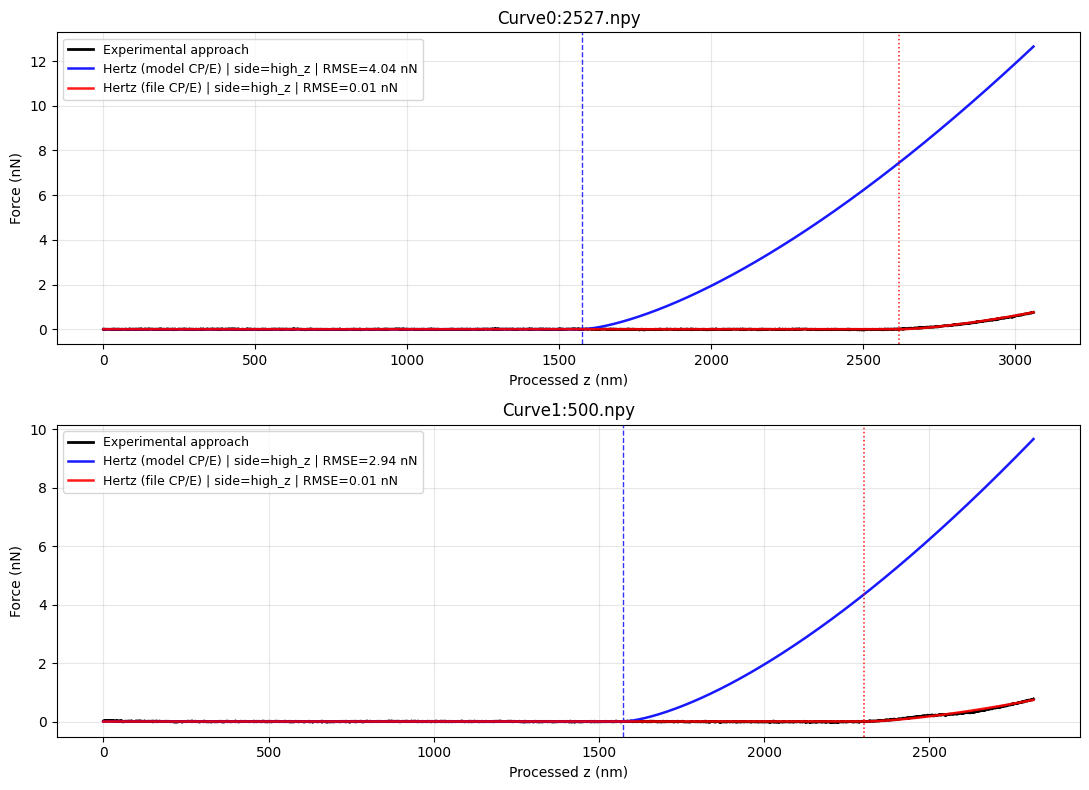

In [32]:
# 6. CONTACT-MECHANICS OVERLAY: MODEL VS FILE REFERENCE

# Use current contact-model geometry if available, otherwise fall back to a
# typical AFM value used above.
if "contact_model" in globals() and hasattr(contact_model, "R"):
    tip_radius_m = float(contact_model.R)
else:
    tip_radius_m = 1000e-9

# Use Poisson ratio from contact model when available.
if "contact_model" in globals() and hasattr(contact_model, "nu"):
    nu = float(contact_model.nu)
else:
    nu = 0.5

hertz_prefactor = (4.0 / 3.0) * np.sqrt(tip_radius_m) / (1.0 - nu**2)

def hertz_force_from_cp_and_e(
    z_m: np.ndarray,
    cp_m: float,
    e_pa: float,
    force_exp_n: np.ndarray,
    ) -> tuple[np.ndarray, str, float]:
    """Compute Hertz force from (cp, E) and choose best contact side.

    Two indentation directions are tested:
    - high-z contact: delta = max(z - cp, 0)
    - low-z contact : delta = max(cp - z, 0)

    The direction with lower RMSE to experimental force is selected.
    """
    z_m = np.asarray(z_m, dtype=np.float64)
    force_exp_n = np.asarray(force_exp_n, dtype=np.float64)

    delta_high = np.clip(z_m - cp_m, 0.0, None)
    force_high = hertz_prefactor * float(e_pa) * np.power(delta_high, 1.5)
    rmse_high = float(np.sqrt(np.mean((force_high - force_exp_n) ** 2)))

    delta_low = np.clip(cp_m - z_m, 0.0, None)
    force_low = hertz_prefactor * float(e_pa) * np.power(delta_low, 1.5)
    rmse_low = float(np.sqrt(np.mean((force_low - force_exp_n) ** 2)))

    if rmse_high <= rmse_low:
        return force_high, "high_z", rmse_high
    return force_low, "low_z", rmse_low


current_curve_mode = globals().get(
    "experimental_curve_mode",
    globals().get("checkpoint_curve_mode", "approach"),
)
print(f"Overlay curve mode: {current_curve_mode}")

if "comparison_df" not in globals() or comparison_df.empty:
    print("No comparison table found. Run the previous prediction cell first.")
else:
    n_show = len(comparison_df)
    fig, axes = plt.subplots(
        n_show,
        1,
        figsize=(11, max(4.5, 4.0 * n_show)),
        squeeze=False,
    )

    for i in range(n_show):
        ax = axes[i, 0]

        z_m_full = np.asarray(z_phys_list[i], dtype=np.float64)
        f_exp_n_full = np.asarray(f_phys_list[i], dtype=np.float64)
        z_nm_full = z_m_full * 1e9

        if "phase_list" in globals() and i < len(phase_list):
            phase_curve = np.asarray(phase_list[i], dtype=np.float64)
        else:
            phase_curve = None

        has_phase_labels = (
            phase_curve is not None and phase_curve.shape == z_m_full.shape
        )
        has_retract_segment = bool(
            has_phase_labels and np.any(phase_curve < 0) and
            np.any(phase_curve > 0)
        )

        if has_retract_segment:
            approach_mask = phase_curve < 0
            retract_mask = phase_curve > 0
            ax.plot(
                z_nm_full[approach_mask],
                f_exp_n_full[approach_mask] * 1e9,
                color="black",
                lw=2.0,
                label="Experimental approach",
            )
            ax.plot(
                z_nm_full[retract_mask],
                f_exp_n_full[retract_mask] * 1e9,
                color="dimgray",
                lw=1.6,
                alpha=0.9,
                label="Experimental retract",
            )
            z_m = z_m_full[approach_mask]
            f_exp_n = f_exp_n_full[approach_mask]
        else:
            ax.plot(
                z_nm_full,
                f_exp_n_full * 1e9,
                color="black",
                lw=2.0,
                label="Experimental approach",
            )
            z_m = z_m_full
            f_exp_n = f_exp_n_full

        z_nm = z_m * 1e9

        # Model-predicted parameters
        cp_pred_m = np.nan
        e_pred_pa = np.nan
        if "pred_cp_nm" in comparison_df.columns and \
          pd.notna(comparison_df.loc[i, "pred_cp_nm"]):
            cp_pred_m = float(comparison_df.loc[i, "pred_cp_nm"]) * 1e-9
        if "pred_stiffness_kpa" in comparison_df.columns and \
          pd.notna(comparison_df.loc[i, "pred_stiffness_kpa"]):
            e_pred_pa = float(comparison_df.loc[i, "pred_stiffness_kpa"]) * 1e3

        if np.isfinite(cp_pred_m) and np.isfinite(e_pred_pa) and e_pred_pa > 0:
            f_pred_n, side_pred, rmse_pred_n = hertz_force_from_cp_and_e(
                z_m=z_m,
                cp_m=cp_pred_m,
                e_pa=e_pred_pa,
                force_exp_n=f_exp_n,
            )
            ax.plot(
                z_nm,
                f_pred_n * 1e9,
                color="blue",
                lw=1.8,
                alpha=0.9,
                label=(
                    f"Hertz (model CP/E) | side={side_pred} | "
                    f"RMSE={rmse_pred_n*1e9:.2f} nN"
                ),
            )
            ax.axvline(
                cp_pred_m * 1e9,
                color="blue",
                ls="--",
                lw=1.0,
                alpha=0.8)

        # File-reference parameters (CP from file adapted to processed z,
        # E from file)
        cp_ref_m = np.nan
        e_ref_pa = np.nan
        if extracted_data["cp_m"][i] is not None:
            cp_raw_m = float(extracted_data["cp_m"][i])
            z_offset_m = float(preprocess_info_list[i].get("z_offset_m", 0.0))
            z_phys_orig_max_m = \
            float(preprocess_info_list[i].get("z_phys_orig_max_m", 0.0))
            cp_phys_orig = aec.adapt_cp_to_processed_z(cp_raw_m, z_offset_m)
            cp_ref_m = z_phys_orig_max_m - cp_phys_orig
        if extracted_data["E_pa"][i] is not None:
            e_ref_pa = float(extracted_data["E_pa"][i])

        if np.isfinite(cp_ref_m) and np.isfinite(e_ref_pa) and e_ref_pa > 0:
            f_ref_n, side_ref, rmse_ref_n = hertz_force_from_cp_and_e(
                z_m=z_m,
                cp_m=cp_ref_m,
                e_pa=e_ref_pa,
                force_exp_n=f_exp_n,
            )
            ax.plot(
                z_nm,
                f_ref_n * 1e9,
                color="red",
                lw=1.8,
                alpha=0.9,
                label=(
                    f"Hertz (file CP/E) | side={side_ref} | "
                    f"RMSE={rmse_ref_n*1e9:.2f} nN"
                ),
            )
            ax.axvline(cp_ref_m * 1e9, color="red", ls=":", lw=1.1, alpha=0.9)

        file_label = (
            comparison_df.loc[i, "filename"]
            if "filename" in comparison_df.columns
            else f"Curve {i}"
        )
        curve_label = "approach+retract" if has_retract_segment \
        else "approach-only"
        ax.set_title(f"Curve{i}:{os.path.basename(str(file_label))}")
        ax.set_xlabel("Processed z (nm)")
        ax.set_ylabel("Force (nN)")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9, loc="best")

    plt.tight_layout()
    os.makedirs("results", exist_ok=True)
    overlay_path = "results/hertz_overlay_model_vs_file.png"
    plt.savefig(overlay_path, dpi=160, bbox_inches="tight")
    print(f"Saved overlay figure to: {overlay_path}")
    plt.show()